[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/gist/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/lecture_10.ipynb)

# Transformers

## History

💬 Have you heard of transformers?

Transformers have been proposed by Google in the 2017 landmark paper [Attention Is All You Need](https://doi.org/10.48550/arXiv.1706.03762) and have led to the development of pre-trained systems such as GPT and BERT. They consistently dominate benchmarks and leaderboards in natural language processing and are well suited also for other modalities such as image, sound, and video. The main innovation is the attention mechanism, which weighs the importance of different words or elements in an input sequence, and which replaces recurrent or convolutional networks in previous architectures.  

<img src="https://gist.github.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/fbabd2f0ef74ebff7f6e52e85cbbf5100c86dfac/lecture_10_transformer_family.png" width="1000px"/>

[(Munson 2025)](https://doi.org/10.1007/s44163-025-00334-5)

This lecture explores transformers independently of their NLP application, within the broader context of time series analysis, thereby facilitating a transfer to financial applications and a comparison to alternative time series models. We focus on GPT-syle models, which are both particularly well suited for this task and particularly successful.

## Code

Please load the definitions by executing the cells but skip the section at first reading.

This section defines a miniature version of GPT, which goes back to [Andrej Karpathy](https://github.com/karpathy/nn-zero-to-hero) and is similar to the reference implementation in [PyTorch](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py) but carries a distributional output layer much like [Huggingface](https://github.com/huggingface/transformers/tree/main/src/transformers)'s time series transformers.

Libraries:

In [ ]:
import math
from pathlib import Path
from typing import Any, Protocol
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from IPython.display import clear_output, display  # noqa: A004
from torch import Tensor, softmax
from torch.nn import Dropout, Embedding, LayerNorm, Linear, Module, ModuleList, ReLU, Sequential

%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
url = "https://raw.githubusercontent.com/ryanmccrickerd/rough_bergomi/6a04ca5d2d0f6a45df28ae7bad9c882d537ef14e/rbergomi"
path = str(Path.cwd())
if not Path(path + "/rbergomi.py").exists():
    urlretrieve(url + "/rbergomi.py", path + "/rbergomi.py")
if not Path(path + "/utils.py").exists():
    urlretrieve(url + "/utils.py", path + "/utils.py")

In [ ]:
from rbergomi import rBergomi
from utils import bsinv

Input:

In [ ]:
class TokenEmbedding(Module):
    """A trainable mapping from integers into a vector space."""
    def __init__(self, *, C: int, E: int = 64, T_max: int = 32, **_: Any) -> None:
        super().__init__()
        self.token_embedding = Embedding(C, E)
        self.position_embedding = Embedding(T_max, E)

    def forward(self, x: Tensor) -> Tensor:
        _B, T = x.shape
        x = self.token_embedding(x)  # (B, T, C) -> (B, T, E)
        pos_emb = self.position_embedding(torch.arange(T, device=x.device))  # (T, E)
        return x + pos_emb  # (B, T, E)


class PositionEncoding(Module):
    """A non-trainable encoding of token positions as sines and cosines."""
    def __init__(self, *, F: int, T_max: int = 5000, **_: Any):
        super().__init__()
        position = torch.arange(T_max).unsqueeze(1) # (T_max, 1)
        frequencies = torch.exp(torch.arange(0, F, 2) * (-math.log(2.*T_max) / F)) # (ceil(F/2), )
        pe = torch.zeros(T_max, F)
        pe[:, 0::2] = torch.sin(position * frequencies) # (T_max, ceil(F/2))
        pe[:, 1::2] = torch.cos(position * frequencies)[:, :math.floor(0.5*F)] # (T_max, floor(F/2))
        self.register_buffer("pe", pe)

    def forward(self, x: Tensor) -> Tensor:
        if len(x.shape) == 2:
            x = x.unsqueeze(-1)
        B, T, _E = x.shape
        _T_max, F = self.pe.shape
        pe = self.pe[: T].unsqueeze(0).expand(B, T, F) # (T_max, F) -> (B, T, F)
        return torch.cat([x, pe[: x.size(0)]], dim=-1) # (B, T, E+F)

Output:

In [ ]:
import torch.distributions.utils


class Output(Protocol):
    def __init__(self, _: Tensor) -> None: ...

    def log_prob(self, _: Tensor) -> Tensor: ...

    def sample(self) -> Tensor: ...


class ScalarOutput(torch.distributions.Normal):
    def __init__(self, x: Tensor) -> None:
        assert x.shape[-1] == 1
        x = x.squeeze(-1)
        super().__init__(loc=x, scale=torch.ones_like(x))

    def sample(self) -> Tensor:
        return self.loc


class CategoricalOutput(torch.distributions.Categorical):
    def __init__(self, x: Tensor) -> None:
        super().__init__(logits=x)


class NormalOutput(torch.distributions.Normal):
    def __init__(self, x: Tensor) -> None:
        loc, scale = torch.split(x, split_size_or_sections=1, dim=-1)
        loc, scale = loc.squeeze(-1), scale.squeeze(-1)
        scale = (scale + torch.sqrt(torch.square(scale) + 4.0)) / 2.0  # smoothened RELU
        scale = scale.clamp(min=torch.finfo(scale.dtype).eps)
        super().__init__(loc, scale)


class CenteredNormalOutput(torch.distributions.Normal):
    def __init__(self, x: Tensor) -> None:
        assert x.shape[-1] == 1
        raw = x.squeeze(-1)
        scale = torch.nn.functional.softplus(raw)
        scale = scale.clamp(min=torch.finfo(scale.dtype).eps)
        super().__init__(loc=torch.zeros_like(scale), scale=scale)


class MultivariateNormalOutput(torch.distributions.MultivariateNormal):
    """Multivariate normal distribution with mean `loc` and covariance `scale @ scale.T`."""
    def __init__(self, x: Tensor) -> None:
        E = x.shape[-1]
        N = int(-3 + math.sqrt(9+8*E))//2
        assert N + N*(N+1)//2 == E
        loc = x[..., : N]
        scale = x[..., N :]
        scale = torch.distributions.utils.vec_to_tril_matrix(scale)
        diag = scale.diagonal(dim1=-2, dim2=-1)
        scale = torch.diagonal_scatter(scale, MultivariateNormalOutput.soft_relu(diag), dim1=-2, dim2=-1)
        super().__init__(loc=loc, scale_tril=scale)

    @staticmethod
    def soft_relu(x: Tensor) -> Tensor:
        return (x + torch.sqrt(torch.square(x) + 4.0)) / 2.0  # smoothened RELU

Transformer:

In [ ]:
class AttentionHead(Module):
    """One head of self-attention.

    Shape parameters: batch size B, lenght of token sequence T, maximal length of token sequence T_max
    number of characters C, embedding dimension E, projected embedding dimension P.
    """

    def __init__(self, E: int, P: int, T_max: int, dropout: float = 0.0) -> None:
        super().__init__()
        self.key = Linear(E, P, bias=False)
        self.query = Linear(E, P, bias=False)
        self.value = Linear(E, P, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(T_max, T_max)))
        self.dropout = Dropout(dropout)

    def forward(self, x: Tensor) -> Tensor:
        _B, T, E = x.shape
        # apply linear layers query, key, and value
        q = self.query(x)  # (B, T, E) -> (B, T, P)
        k = self.key(x)  # (B, T, E) -> (B, T, P)
        v = self.value(x)  # (B, T, E) -> (B, T, P)
        # compute attention scores
        attention = q @ k.transpose(-2, -1) * E**-0.5  # (B, T, P) @ (B, P, T) -> (B, T, T)
        attention = attention.masked_fill(self.tril[:T, :T] == 0, float("-inf"))  # (B, T, T)
        attention = softmax(attention, dim=-1)  # (B, T, T)
        attention = self.dropout(attention)  # (B, T, T)
        # aggregate the attention-weighted values
        return attention @ v  # (B, T, T) @ (B, T, P) -> (B, T, P)


class AttentionLayer(Module):
    """Multiple heads of self-attention in parallel.

    Shape parameters: embedding dimension E, projected embedding dimension P,
    number of attention heads H, maximal length of token sequence T_max, number of characters C.
    """

    def __init__(self, E: int, H: int, P: int, T_max: int, dropout: float = 0.0) -> None:
        super().__init__()
        self.heads = ModuleList([AttentionHead(E, P, T_max) for _ in range(H)])
        self.proj = Linear(H * P, H * P)
        self.dropout = Dropout(dropout)

    def forward(self, x: Tensor) -> Tensor:
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, E) -> (B, T, H*P)
        return self.dropout(self.proj(out))  # (B, T, H*P)


class FeedFoward(Module):
    """A fully connected feed-forward network with one hidden layer.

    Shape parameters: embedding dimension E.
    """

    def __init__(self, E: int, dropout: float = 0.0) -> None:
        super().__init__()
        self.net = Sequential(
            Linear(E, 4 * E),
            ReLU(),
            Linear(4 * E, E),
            Dropout(dropout),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class TransformerBlock(Module):
    """Transformer block: communication followed by computation.

    Shape parameters: embedding dimension E, projected embedding dimension P,
    number of attention heads H, maximal length of token sequence T_max.
    """

    def __init__(self, E: int, H: int, T_max: int) -> None:
        super().__init__()
        assert E % H == 0
        P = E // H
        self.attention_layer = AttentionLayer(E, H, P, T_max)
        self.feed_forward = FeedFoward(E)
        self.layer_norm1 = LayerNorm(E)
        self.layer_norm2 = LayerNorm(E)

    def forward(self, x: Tensor) -> Tensor:
        x = x + self.attention_layer(self.layer_norm1(x))  # (B, T, E) -> (B, T, E)
        return x + self.feed_forward(self.layer_norm2(x))  # (B, T, E) -> (B, T, E)


class GPT(Module):
    """GPT-style transformer (decoder-only) with token and positional embeddings.

    Shape parameters: number of distribution parameters D, embedding dimension E,
    number of attention heads H, number of attention layers L, maximal length of token sequence T_max,
    length of predicted sequence T_pred.
    """

    def __init__(
        self,
        embedding: Module,
        *,
        D: int | list[int],
        E: int = 64,
        H: int = 4,
        L: int = 4,
        T_max: int = 32,
        output: type[Output] = CategoricalOutput,
        **_: Any,
    ) -> None:
        super().__init__()
        self.embedding = embedding
        self.transformer_blocks = Sequential(*[TransformerBlock(E, H, T_max) for _ in range(L)])
        self.layer_norm = LayerNorm(E)  # final layer norm
        self.linear = Linear(E, math.prod(D) if isinstance(D, list) else D)
        self.distribution = output
        self.D = D
        self.T_max = T_max

    def forward(self, x: Tensor, targets: Tensor | None = None) -> tuple[Tensor, Tensor | None]:
        x = self.embedding(x) # (B, T, E)
        x = self.transformer_blocks(x)  # (B, T, E) -> (B, T, E)
        x = self.layer_norm(x)  # (B, T, E)
        x = self.linear(x)  # (B, T, D)
        if isinstance(self.D, list):
            x = x.view(x.shape[0], x.shape[1], *self.D) # (B, T, D1, ..., Dn)
        loss = None if targets is None else -self.distribution(x).log_prob(targets).mean()
        return x, loss

    def generate(self, x: Tensor, T_pred: int) -> Tensor:
        # x has shape (B, T, ...)
        B = x.shape[0]
        T0 = x.shape[1]
        extra_shape = x.shape[2:]

        # preallocate full output to avoid repeated torch.cat
        out = torch.empty((B, T0 + T_pred, *extra_shape), dtype=x.dtype, device=x.device)
        out[:, :T0] = x

        for t in range(T_pred):
            current_len = T0 + t
            x_cropped = out[:, max(0, current_len - self.T_max) : current_len]
            y, _ = self(x_cropped)
            y = y[:, -1, :]
            y = self.distribution(y).sample()
            if len(extra_shape) > 0:
                y = y.view(B, *extra_shape)
            out[:, current_len] = y

        return out


Scripts:

In [ ]:
def get_batch(data: Tensor, config: dict) -> tuple[Tensor, Tensor]:
    B = config.get("B", 16)
    T_max = config.get("T_max", 32)
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    ix = torch.randint(len(data) - T_max, (B,))
    x = torch.stack([data[i : i + T_max] for i in ix])
    y = torch.stack([data[i + 1 : i + T_max + 1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y


@torch.no_grad()
def estimate_loss(model: Module, train_data: Tensor, val_data: Tensor, config: dict) -> dict:
    eval_iters = config.get("eval_iters", 200)
    out = {}
    model.eval()
    for split in ["train", "val"]:
        data = train_data if split == "train" else val_data
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(data, config)
            _logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


def train(model: Module, text: str, config: dict) -> None:
    # unpack config
    learning_rate = config.get("learning_rate", 1e-3)
    max_iters = config.get("max_iters", 5000)
    dtype = config.get("dtype", torch.long)
    encode = config.get("encode")
    eval_interval = config.get("eval_interval", 100)
    split = config.get("split")
    transform = config.get("transform")

    # split
    data = torch.as_tensor(text if encode is None else encode(text), dtype=dtype)
    if split is None:
        split = int(0.9 * len(data))
    train_data = data[:split]
    val_data = data[split:]

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    steps: list[int] = []
    train_losses: list[float] = []
    val_losses: list[float] = []

    for i in range(max_iters):

        # every once in a while evaluate the loss on train and val sets
        if i % eval_interval == 0 or i == max_iters - 1:
            losses = estimate_loss(model, train_data, val_data, config)
            steps.append(i)
            train_losses.append(float(losses["train"]))
            val_losses.append(float(losses["val"]))

            clear_output(wait=True)
            fig, ax = plt.subplots()
            ax.plot(steps, train_losses, label="Training", linewidth=2)
            ax.plot(steps, val_losses, label="Validation", linewidth=2)
            ax.set_xlabel("Gradient Steps")
            ax.set_ylabel("Loss")
            ax.set_title("Training and Validation Loss")
            ax.grid(alpha=0.3)
            ax.legend()
            display(fig)
            plt.close(fig)

        # sample a batch of data
        x, y = get_batch(train_data, config)

        # optionally transform the targets
        if transform is not None:
            y = transform(y)

        # evaluate the loss
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()


def generate(model: Module, x: str | Tensor, config: dict) -> Tensor:
    # unpack config
    encode = config.get("encode")
    decode = config.get("decode")
    device = config.get("device", "cuda" if torch.cuda.is_available() else "cpu")
    dtype = config.get("dtype", torch.long)
    T_pred = config.get("T_pred", 1000)

    # support both single-sequence and batched generation
    if encode is not None and isinstance(x, str):
        x = encode(x)

    x = torch.as_tensor(x, dtype=dtype, device=device)
    was_batched_input = x.ndim > 1
    if x.ndim == 1:
        x = x.unsqueeze(0)  # (T, ...) -> (1, T, ...)

    model.eval()
    with torch.inference_mode():
        y = model.generate(x, T_pred)

    if decode is not None:
        if was_batched_input:
            return [decode(row.tolist()) for row in y]
        return decode(y[0].tolist())

    if was_batched_input:
        return y.tolist()
    return y[0].tolist()  # backward-compatible for single input

## Motivation

This section demonstrates the _incredible accessibility_ of transformers for natural language modelling, following some parts of [Andrey Karpathy's fantastic lecture courses](https://github.com/karpathy/nn-zero-to-hero), and then investigates whether the same model can also be applied to other languages.

In [ ]:
# download and inspect tiny shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
path = "tinyshakespeare.txt"
if not Path(path).exists():
    urlretrieve(url, path)

with open(path, encoding="utf-8") as f: # noqa:PTH123
    text = f.read()
print("Length of dataset in characters: ", len(text))
print(f"First 1000 characters: \n\n{text[:1000]}")

Length of dataset in characters:  1115394
First 1000 characters: 

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods 

In [ ]:
# here are all the unique characters that occur in this text
chars = sorted(set(text))
vocab_size = len(chars)
print("".join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [ ]:
# create mappings from characters to integers and back
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }  # noqa: C416
def encode(s): # take a string, output a list of integers
    return [stoi[c] for c in s]
def decode(l): # take a list of integers, output a string
    return "".join([itos[i] for i in l])

print(encode("hi there"))
print(decode(encode("hi there")))

[46, 47, 1, 58, 46, 43, 56, 43]
hi there


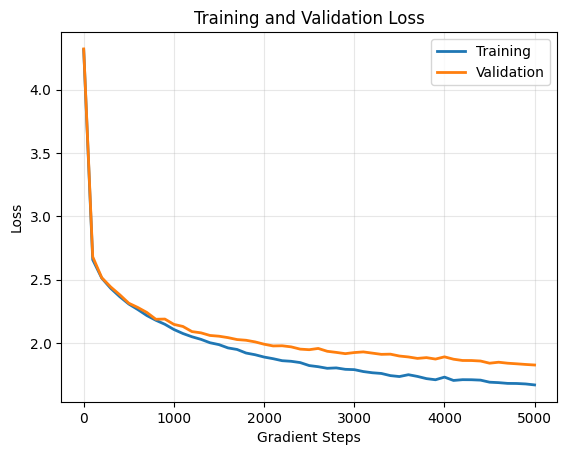

In [ ]:
# train a simple hand-crafted transformer model
config = {
    "C": len(chars),       # how many characters?
    "D": len(chars),       # how many distributional parameters?
    "encode": encode,
    "decode": decode,
    "device": device,
}
embedding = TokenEmbedding(**config).to(device)
model = GPT(embedding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, text, config)

In [ ]:
print(generate(model, "O Julia, Julia, wherefore art thou Julia?\n\n", config))

O Julia, Julia, wherefore art thou Julia?

ROMIO:
I'f ahus heave no it accupores; for the proy of then sorre?

BUCKINGHAMARD:
The bond her life her?
Wold usenged to--dothink me; allo you,-poor more wentence
Fell did his bedies you nefoud have more a thie allieg
ever of but hanves van a warrack mores we ond.

GLUTH:
Prute, afweart's beakles I but to thy talork,
Gaultage stright so buther you thy not be must;
At a readieriess an read, and policioul;
No feelifful, vishre's quoth noist see me
Thy Evellon heaven you detent,--ake is mingelae!

Sirraction fit.
Accous you heave state thee it.

PORIOLANNA:
Myou, nelive, aidon, must me talost mey as shonde wil fear,
And it would Well not recelos.

KUMINIUSH:
No:
She heartier'd.

YORF:
Yome their musbeing
But the wadvannua, ondamed, Buccien
of the pleasition, the with paities: I dow, and state this folk, this man;
For mis manderalor Rastel wanties it;
When but to cruell upon, such
pead, he hands here overy heaven
The tothen me a shall up.lekee of

This sounds at best like drunken Shakespear, but it does give a hint of the right character gestalt. With 4 days of training on a GPU and some hyperparameter tuning, one would [get](https://github.com/karpathy/nanoGPT?tab=readme-ov-file#quick-start) reasonably Shakespearean text.

It seems like a miracle what is happening above. To wit, let us apply the same model in another context, which is well familiar to you. Namely, instead of Shakespeare's writings, let us consider a time series of stock returns according to Robert Engle's Nobel-prize winning model.

100000
200000
300000
400000
500000
600000
700000
800000
900000


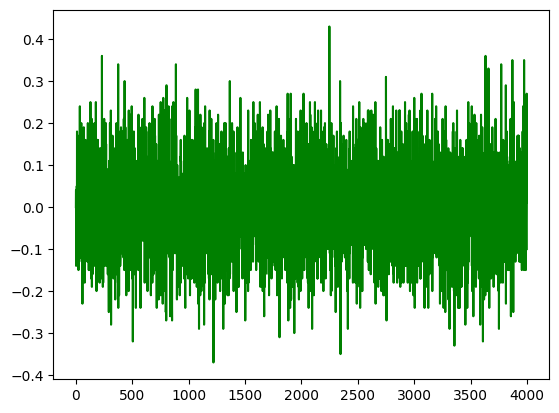

In [ ]:
# create a GARCH-type log_returns
timeseries=np.zeros(10**6)
sigma = 0.1
for t in range(1, 10**6):
    if t % 10**5 == 0:
      print(t)
    sigma = np.sqrt(0.01+0.05*sigma**2+0.04*timeseries[t-1]**2)
    timeseries[t] = np.round(np.random.normal(0., 1.)*sigma,2)

plt.plot(timeseries[:4000], color="green")

In [ ]:
# here are all the unique 'characters' that occur in this timeseries, plus some extra large and extra small ones
chars = sorted(set(timeseries))
chars = chars + [-0.5-i*0.01 for i in range(10)]+[0.5+i*0.01 for i in range(10)]
chars = sorted(set(chars))
vocab_size = len(chars)
print(chars)
print(vocab_size)

[-0.59, -0.58, -0.5700000000000001, -0.56, -0.55, -0.54, -0.53, np.float64(-0.52), -0.51, np.float64(-0.5), np.float64(-0.48), np.float64(-0.47), np.float64(-0.46), np.float64(-0.45), np.float64(-0.44), np.float64(-0.43), np.float64(-0.42), np.float64(-0.41), np.float64(-0.4), np.float64(-0.39), np.float64(-0.38), np.float64(-0.37), np.float64(-0.36), np.float64(-0.35), np.float64(-0.34), np.float64(-0.33), np.float64(-0.32), np.float64(-0.31), np.float64(-0.3), np.float64(-0.29), np.float64(-0.28), np.float64(-0.27), np.float64(-0.26), np.float64(-0.25), np.float64(-0.24), np.float64(-0.23), np.float64(-0.22), np.float64(-0.21), np.float64(-0.2), np.float64(-0.19), np.float64(-0.18), np.float64(-0.17), np.float64(-0.16), np.float64(-0.15), np.float64(-0.14), np.float64(-0.13), np.float64(-0.12), np.float64(-0.11), np.float64(-0.1), np.float64(-0.09), np.float64(-0.08), np.float64(-0.07), np.float64(-0.06), np.float64(-0.05), np.float64(-0.04), np.float64(-0.03), np.float64(-0.02), np.

In [ ]:
# redefine the mappings from characters to integers and back
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }  # noqa: C416
def encode(s): # take a list of floats, output a list of integers
    return [stoi[c] for c in s]
def decode(l): # take a list of integers, output a string
    return [itos[i] for i in l]

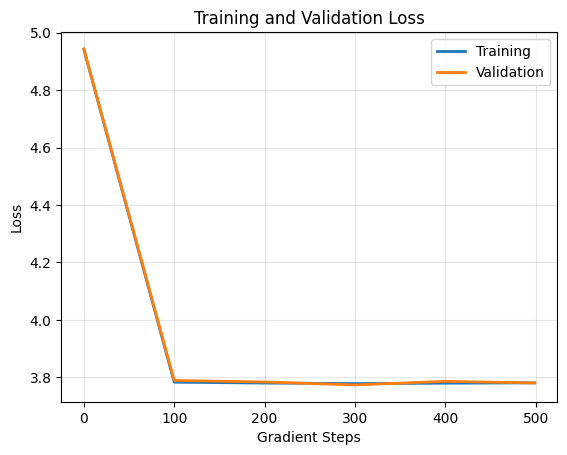

In [ ]:
# train the same transformer model on the new data
config = {
    "C": len(chars),       # how many characters?
    "D": len(chars),       # how many distributional parameters?
    "E": 128,              # more embeddings per token
    "T_pred": 4000,        # more predictions
    "encode": encode,
    "decode": decode,
    "max_iters": 500,     # less training
}
embedding = TokenEmbedding(**config).to(device)
model = GPT(embedding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

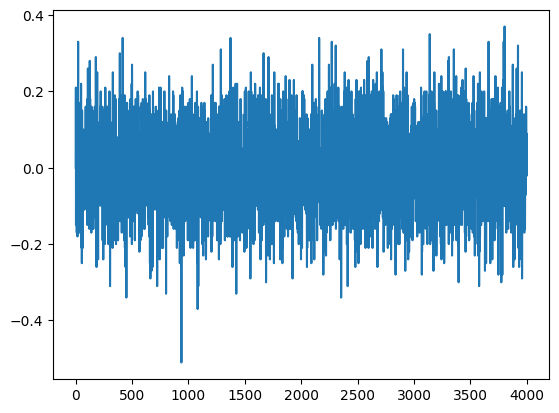

In [ ]:
output = generate(model, [0.0], config)
plt.plot(output)

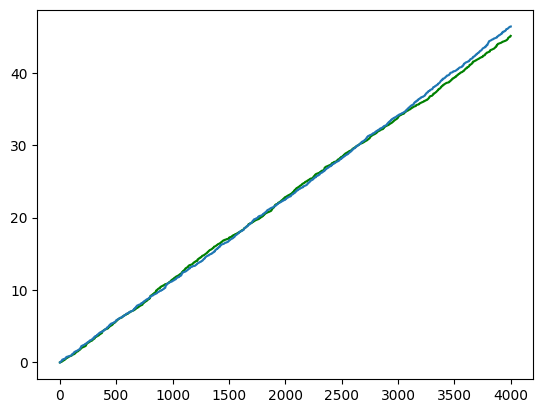

In [ ]:
plt.plot(np.cumsum(timeseries[:4000]**2),color="green")
plt.plot(np.cumsum(np.array(output)**2))

(array([1.000e+00, 3.000e+00, 4.400e+01, 2.520e+02, 6.620e+02, 1.251e+03,
        1.133e+03, 5.200e+02, 1.140e+02, 2.100e+01]),
 array([-0.51 , -0.422, -0.334, -0.246, -0.158, -0.07 ,  0.018,  0.106,
         0.194,  0.282,  0.37 ]),
 <BarContainer object of 10 artists>)

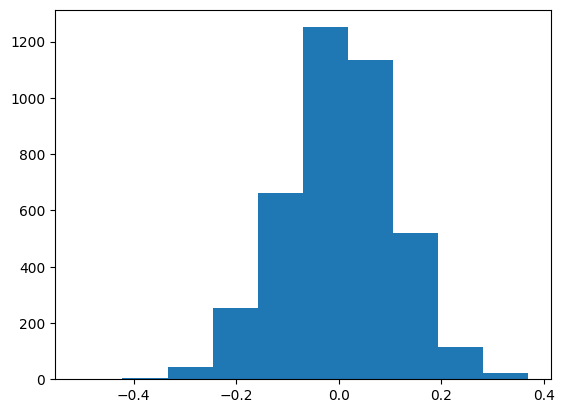

In [ ]:
plt.hist(np.array(output))

(array([   7.,   66.,  335.,  966., 1167.,  838.,  477.,  120.,   19.,
           5.]),
 array([-0.37, -0.29, -0.21, -0.13, -0.05,  0.03,  0.11,  0.19,  0.27,
         0.35,  0.43]),
 <BarContainer object of 10 artists>)

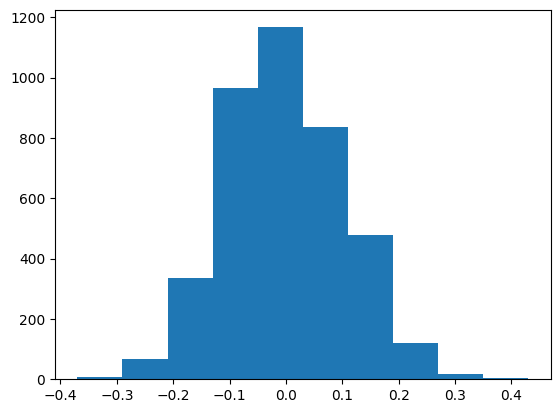

In [ ]:
plt.hist(timeseries[:4000])

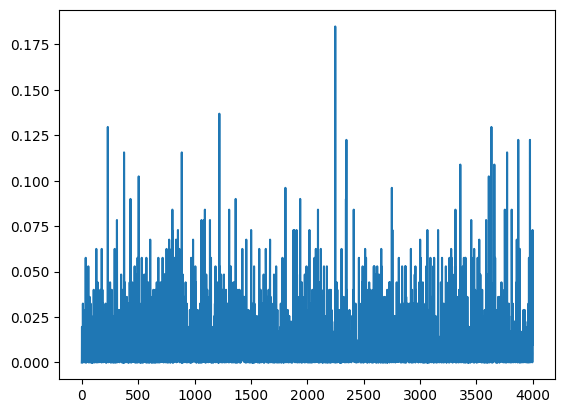

In [ ]:
plt.plot(timeseries[:4000]**2)

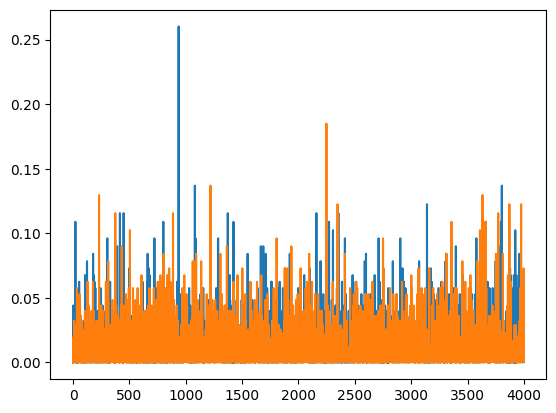

In [ ]:
plt.plot(np.array(output)**2)
plt.plot(timeseries[0:4000]**2)

We have seen that transformers adapt readily from generating natural language to generating financial time series. There are myriads of further examples in [computer vision](https://doi.org/10.48550/arXiv.2101.01169), [audio](https://magenta.tensorflow.org/music-transformer) and [video](https://doi.org/10.48550/arXiv.2201.05991) applications, all the way to playing [chess](https://doi.org/10.48550/arXiv.2008.04057) or performing [symbolic computations](https://doi.org/10.48550/arXiv.2110.03501).
The widespread applicability of transformers suggests that these can be understood as general time series models.

## Transformers as time series models

This section explains how learning Shakespeare and learning stock prices can be seen as different instances of the same time series analysis task. It also exhibits the main modeling assumptions behind transformers.

**Definition (Time series).**
Let $T$ be a set of time indices, and let $F$ be a set of features.
A time series is a random function $x:T\to F$ or, equivalently, a random element $x \in F^T$.

Two common statistical tasks in time series analysis are:

- **Predicting** a distribution over future time series given past time series data
- **Simulating** random samples of future time series given past time series data

Both tasks involve learning general sequence-to-sequence mappings, which is difficult because:

- Time series data tends to be high-dimensional
- There may be only few samples to learn from, e.g. a single text of Shakespeare or a single historical trajectory of a stock price.

These difficulties can be alleviated via the following two simplifying assumptions, which break down the complexity of the learning task and also increase the number of samples to learn from.

**Assumption (Temporal causation).**
A time series is temporally causal if the present is a deterministic function of the past and independent random noise:

$$\forall t \in T: \qquad x_t = f(t, x_{<t}, u_t), \qquad \text{for some iid. random variables $u_t$.}$$

Note that besides defining a temporal order, this also rules out any hidden states, i.e., all information which is relevant for the time series dynamics is captured in the values of the time series.

💬 Who is aware that there is a mathematical definition of causality?

This is a special case of a more general definition of causality, which goes back to [Pearl](https://doi.org/10.1017/CBO9780511803161), is merely 15 years old, and resolves a question which may be as old as humanity itself. According to Pearl's definition, a causal model is a directed acyclic graph between random variables $X_i$ with the following meaning: Each random variable $X_i$ is some deterministic function $f_i$ of its parents and of some other random variable $U_i$, such that all random variables $U_i$ are mutually independent. This notion of causality has taken econometrics by storm and has found applications in explainable AI and reinforcement learning. Temporal causation corresponds to the special case where the directed graph is given by the relation of temporal precedence.

**Assumption (Temporal homogeneity).**
A time series $x$ is temporally homogeneous if its present is _the same_ deterministic function of past values and independent random noise:

$$\forall t \in T: \qquad x_t=f(x_{<t},u_t), \qquad \text{for some iid. random variables $u_t$.}$$

💬 What would it take to turn an inhomogeneous time series into a homogeneous one?

Thanks to the above assumptions, it is sufficient to learn a single sequence-to-point function instead of many sequence-to-sequence functions.
Moreover, for any given time series, there are as many training samples as there are time points.
For practical purposes, the history $x_{<t}$ is often truncated to some fixed number of past values, leading to autoregressive time series models.

**Definition (Autoregressive Time Series Model).**

- An autoregressive time series model of order $k$ is a function $f:F^k\times U \to F$ or, equivalently, a probability kernel $p:F^k \to \mathcal P(F)$.
- For training, one maximizes the likelihood of all substrings $(x, y) \in F^k \times F$ of a given time series (or of a dataset of time series).
- For generation, one samples $x_t$ given $x_{t-1}, \dots, x_{t-k}$ autoregressively.

**Example (Transformers).**
The transformer model, which was used to learn Shakespeare and stock returns,

- is an autoregressive model of order 32, and
- predicts discrete probability distributions over some alphabet of characters or discretized stock returns.

💬 Are the assumptions of temporal causality and homogeneity realistic in financial or linguistic modeling?

## Transformer architecture

This section defines the main elements of the transformer architecture both in pictures and formulas. It is recommended to read the definitions in parallel with the source code.

**Encoders and decoders.**
The original transformer architecture, as introduced by Google in [Attention Is All You Need](https://doi.org/10.48550/arXiv.1706.03762), combines an encoder block (left) and a decoder block (right). There is an attention mechanism within the encoder and decoder block, and there is cross-attention between them. This architecture is used i.a. in Google's Text-To-Text Transfer Transformers (T5) for natural language processing.

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_transformer.png" width="300px"/>

Some important architectural variants are encoder-only models like [BERT](https://doi.org/10.48550/arXiv.1810.04805) and decoder-only models like [GPT](https://doi.org/10.48550/arXiv.2303.08774). The main difference between encoders and decoders is that decoders have a causal mask, which ensures that output tokens can attend only to past input tokens. For simplicity, and because of their wide adoption in language modeling, we shall focus on decoder-only architectures.

**Tokenization and Input Embedding.**

- Tokenization transforms the text into a list of integers, called tokens (think: 30k tokens corresponding to 3-4 characters each, plus some special start/end tokens).
- A context window of at most $n$ subsequent tokens can be processed at any time (think: $n=$ 10k)
- The tokens are vectorized using fixed or trainable embeddings into some $d$-dimensional Euclidean space (think: $d=$ 1k).
- The token positions are vectorized using fixed or trainable embeddings into the same Euclidean space.
- Token and position embeddings are added up and fed as inputs to the transformer model.

**Definition (Transformer).**
A transformer is a composition of transformer blocks. In formulas, a transformer is a function
$$
T:\mathbb R^{n\times d}\rightarrow\mathbb R^{n\times d},
\qquad
T(X):=(B_\ell\circ B_{\ell-1}\circ\dots\circ B_1)(X),  
$$
where $\ell\in\mathbb N$ and $B_1,\dots,B_\ell$ are transformer blocks.

**Notation.** We shall write $n$ for the length of the time series and $d$ for the number of spatial features.

**Definition (Transformer Block).**
A transformer block is a self-attention layer followed by a fully connected feed-forward network with residual connections, in formulas:
$$
B:\mathbb R^{n\times d}\rightarrow\mathbb R^{n\times d},
\qquad
B(X)=(\operatorname{Id}+F)\circ (\operatorname{Id}+A)(X),
$$
where $A:\mathbb R^{n\times d}\rightarrow\mathbb R^{n\times d}$ is a self-attention layer, and $F:\mathbb R^{d}\rightarrow\mathbb R^{d}$ is a fully connected network, applied identically to each token. (In practice, to stabilize training, layer normalization is added after the residual connections, but this is omitted here.)

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_transformer_block.png" width="100px"/>

**Definition (Self-Attention Layer).**
A self-attention layer is a function $X\mapsto A(X, X, X)$, where $A$ is an attention layer.
An attention layer is a linear combination of attention heads, in formulas:
$$
A:\mathbb R^{n\times d} \times \mathbb R^{n\times d} \times \mathbb R^{n\times d}\to\mathbb R^{n\times d},
\qquad
A(Q, K, V) =  \big(A_1(Q, K, V),\dots,A_h(Q, K, V)\big) W_O,
$$
where $h\in\mathbb N$, $A_1,\dots,A_h$ are attention heads, and $W_O\in\mathbb R^{hd\times d}$.

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_attention_layer.png" width="150px"/>

**Definition (Attention head).**
An attention head is a function
$$
A: \mathbb R^{n\times d} \times  \mathbb R^{n\times d} \times  \mathbb R^{n\times d} \to \mathbb R^{n\times d},
\qquad
A(Q, K, V)=\underbrace{\rho\Big((QW_Q)(KW_K)^\top / \sqrt{d}\Big)}_{\text{attention matrix}} VW_V,
$$
where $W_Q, W_K, W_V \in \mathbb R^{d\times d}$ are weight matrices, and $\rho: \mathbb R^{n\times n} \to \mathbb R^{n \times n}$ is the softmax function (applied row-wise).
(For decoding, a mask is applied to the softmax inputs, with the effect of deleting all entries strictly above the diagonal, but this is omitted here. See the [paper](https://doi.org/10.48550/arXiv.1706.03762) or [code](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py) for further details.)

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_attention_head.png" width="100px"/>

**Remark (Intuition for Attention in Linguistics).** Consider the sentence: Alice gave Bob her book. As the pronoun _her_ refers to _Alice_, we expect a large attention weight on _Alice_ in the output representation for _her_:
$$
\operatorname{output}(her) = \sum_{word \in \{Alice, gave, Bob, her\}} \operatorname{attention}(her, word) \operatorname{value}(word).
$$
The attention is computed similarly as in semantic search, namely using inner products between vector embeddings of queries and keys.

**Training and Generation.**
For performance reasons, all token likelihoods in any given sample are computed in parallel:

- Identical copies of the model $f: \mathbb R^{n\times d} \to \mathbb R^d$ are put together to form a sequence-to-sequence mapping $f: \mathbb R^{n\times d} \to \mathbb R^{n\times d}$.
- The model is tasked with predicting $(x_1, \dots, x_n)$ given $x=(s, x_1, \dots, x_{n-1})$, for some special start token $s$.

Hence, decoders are trained on left-shifts (and encoders on some other unmasking tasks). Due to autoregressivity, this token-level parallelization is not possible for generation (but speculative decoding offers some work-arounds).

## Evolution systems and Takens theorem

Transformers learn left shifts, aka. evolution systems, and we shall see in this section that these are nearly as general as generic dynamical systems.

**Definition (Evolution System).**
An evolution system is a dynamical system on $\mathcal X^n$, whose transition function is of the form
$$
\mathcal X^n \to \mathcal X^n,
\qquad
(x_1, \dots, x_n) \mapsto \big(x_2, \dots, x_n, f(x_1, \dots, x_n)\big),
$$
for some forecasting function $f$.

Compared to general dynamical systems, this requires the state space to be a product and the transition function to be a left-shift, for all but the last factor. This assumption turns out to be less strict than it may seem, at least from a topological perspective. To facilitate this topological comparison, we introduce an equivalence relation between dynamical systems.

**Definition (Topological Conjugacy).**
Two dynamical systems with transition functions $f:M \to M$ and $g:N\to N$ are called topologically conjugate if there exists a homeomorphism $h:N\to M$ such that $f = h \circ g \circ h^{-1}$.

Note that conjugacy of $f$ and $g$ implies conjugacy of $f^k$ and $g^k$, for all $k$. Hence, the dynamics of one system can be expressed equivalently in terms of the other system. [Taken's embedding theorem](https://doi.org/10.1007/BFb0091924) asserts that any generic dynamical system is equal, up to topological conjugacy, to an evolution system on some emdbedded manifold. The precise statement in the following form is due to [Huke (2006)](https://eprints.maths.manchester.ac.uk/175/1/embed.pdf.).

**Theorem (Takens Embedding).**
Let $M$ be a compact $m$-dimensional manifold and let $f:M\to M$ be a twice-differentiable diffeomorphism.
Assume that $f$ has only finitely many periodic points with period $\leq 2m$, and that at any such point $x$, the eigenvalues of the differential $T_xf^k:T _x M \to T_xM$ are distinct.
Then, for any generic $C^2$ read-out function $r: M\to\mathbb R$, the following function is a $C^1$ embedding:
$$
M \to \mathbb{R}^{2m+1},
\qquad
x \mapsto \left(r(x), r \circ f(x), r \circ f^2 (x), \ldots, r \circ f^{2m} (x)\right).
$$
In particular, this function is a homeomorphism onto its image and defines a topological conjugacy between the dynamical system with transition function $f$ and the evolution system with the above context window of observations.

The take-away is that generic dynamical systems can be learned directly from context windows of past observations. These past observations may contain only very limited information, as in the case of a scalar read-out. An important limitation is that Takens' embedding theorem treats only deterministic dynamics. This limitation is addressed in generalizations of Takens' embedding theorem to forced and random dynamical systems (e.g. [Stark et al. 1997](https://doi.org/10.1016/S0362-546X(96)00149-6)).

## Universality

💬 What is the definition of universality, and does the universal approximation theorem apply to transformers?

💬 What happens to a transformer's output when the input sequence is permuted (ignoring positional embedding and causal masking)?

Following [Alberti et al. (2023)](https://arxiv.org/pdf/2307.02301), which is a strengthened and simplified version of [Yun et al. (2020)](https://arxiv.org/pdf/1912.10077), we shall view transformers as sequence-to-sequence mappings $\mathcal X^n \to \mathcal Y^n$, where $n \in \mathbb N$, $\mathcal X,\mathcal Y\subseteq\mathbb R^d$, and $\mathcal X$ is assumed to be compact. Note that $\mathcal X$ and $\mathcal Y$ may live in spaces with different dimensions.

**Definition (Equivariance).**
A sequence-to-sequence function $f:\mathcal X^n\rightarrow\mathcal Y^n$ is equivariant if for each permutation $\pi:[n]\rightarrow[n]$,
$$
    f(x_{\pi(1)}, \dots, x_{\pi(n)}) = \big(f_{\pi(1)}(x), \dots, f_{\pi(n)}(x)\big).
$$

Transformers are equivariant, as one verifies easily. (That is, unless an attention mask is used.)
The equivariant continuous functions constitute a closed subspace of the space of all continuous functions (why?).
Therefore, transformers cannot be dense in the space of all continuous functions but merely, at best, in the subspace of equivariant ones.

To gain a better understanding for the space of equivariant functions, we introduce the notion of semi-invariance or, in the terminology of [Hutter (2020)](https://arxiv.org/pdf/2007.15298), all-but-one symmetry.

**Definition (Semi-Invariance)**
A sequence-to-point function $g:\mathcal X^n\rightarrow\mathcal Y$ is semi-invariant if for each permutation $\pi:[n]\setminus\{1\}\rightarrow [n]\setminus\{1\}$:
$$
    g(x_1,x_2,\dots,x_n)=g(x_1,x_{\pi(2)},\dots,x_{\pi(n)}).
$$

The virtue of this definition stems from the following relation between equivariant sequence-to-sequence mappings and semi-invariant sequence-to-point mappings [(Hutter 2020)](https://arxiv.org/pdf/2007.15298).

**Lemma.**
A sequence-to-sequence function $f:\mathcal X^n\rightarrow\mathcal Y^n$ is equivariant if and only if there exists a semi-invariant sequence-to-point function $g:\mathcal X^n\rightarrow\mathcal Y$ such that
$$
    f(x_1,\dots,x_n)=\Big(g\big(x_1,(x_2,\dots, x_n)\big),\dots,g\big(x_n,(x_1,\dots,x_{n-1})\big)\Big).
$$

**Sketch of Proof.**
Given $f$, define $g:=f_1$ and verify that $g$ is semi-invariant. Conversely, given $g$, define $f_1:=g$ and reconstruct the remaining coordinates of $f$ using the equivariance of $f$. $\Box$

Building on this lemma, we next show that any equivariant function can be approximated by compositions of sums and bivariate functions. This statement is remarkably easy to prove and also lends itself to implementation via neural networks. Its non-equivariant counterpart is the infamous [Kolmogorov-Arnold theorem](https://en.wikipedia.org/wiki/Kolmogorov–Arnold_representation_theorem), which enjoys neither of these properties but provides an exact representation as opposed to an approximation.

**Definition (Sumformer)**
A sumformer is a sequence-to-sequence function $\mathcal S:\mathcal X^n\rightarrow\mathcal Y^n$ of the form
$$\mathcal S(x_1,\dots,x_n):=\Big(\psi(x_1,\Sigma),\dots,\psi(x_n,\Sigma)\Big),\qquad \Sigma:=\sum_{k=1}^n\phi(x_k),$$
for some $d'\in\mathbb N$ and some continuous functions $\phi:\mathcal X\rightarrow\mathbb R^{d'}$ and $\psi:\mathcal X\times\mathbb R^{d'}\rightarrow\mathcal Y$.

**Theorem (Universality of Sumformers).**
For each continuous permutation-equivariant function $f:\mathcal X^n\to\mathcal Y^n$ and for each $\epsilon>0$ there exists a sumformer $\mathcal S$ such that
$$\sup_{X\in\mathcal X^n}\|f(X)-\mathcal S(X)\|_\infty<\epsilon.$$

**Proof.**
We shall write $\alpha, \beta \in [d]$ for spatial indices and $i, j \in [n]$ for temporal indices.
Using Stone-Weierstrass, we approximate every spatial coordinate $f_\alpha$ by a polynomial $p_\alpha: \mathcal X^n \mapsto \mathbb R^n$ such that $\|f_\alpha-p_\alpha\|_\infty\leq \epsilon / d$.
Let $\bar p$ be the symmetrization of $p$, defined as
$$
    \bar p = \frac{1}{n!}\sum_{\pi} S_{\pi}^{-1} \circ p \circ S_\pi,
    \qquad
    S_\pi(x_1, \dots, x_n) = \big(x_{\pi(1)}, \dots, x_{\pi(n)}\big),
$$
where $\pi$ runs through all permutations of $[n]$.
Then, $\|\bar p-f\|\leq\|p-f\|$, as one verifies using the equivariance of $f$ and the invariance of the norm.
Hence, we assume in the sequel that $p$ is already symmetrized, hence equivariant.
By the above lemma, every spatial coordinate $p_\alpha$ can be represented as
$$p_\alpha(x_1, \ldots, x_n)=\Big(q_\alpha\big(x_1, (x_2, \ldots, x_n)\big), \ldots, q_\alpha\big(x_n, (x_1, \ldots, x_{n-1})\big)\Big),$$
for some semi-invariant polynomial $q_\alpha:\mathcal X^n \mapsto \mathbb R$.
Let $\phi:\mathbb R^d \mapsto \mathbb R^{d'}$ be the map to all $d'$ multisymmetric monomials with order $>0$ and $\leq n$.
Then, $q_\alpha$ can be [represented](https://eudml.org/doc/124600) as
$$q_\alpha\big(x_i, (\ldots, x_{i-1}, x_{i+1}, \ldots)\big) = \sum_{\beta \in B} x_i^\beta \cdot \sigma_\beta\Big(\sum_{j\in[n], j\neq i} \phi(x_j)\Big),$$
for some polynomials $\sigma_\beta$ indexed over a finite set $B$ of multi-indices $\beta \in \mathbb{N}_0^d$.
Let $\Sigma = \sum_{j=1}^n \phi (x_j)$. (This will be the sum in the sumformer.) Then,
$$q_\alpha\big(x_i, (\ldots, x_{i-1}, x_{i+1}, \ldots)\big) = \sum_{\beta \in B} x_i^\beta \cdot \sigma_\beta\big(\Sigma - \phi(x_i)\big).$$
The right-hand side is a polynomial $\psi_\alpha$ in the variables $x_i$ and $\Sigma$, resulting in the representation
$$q_\alpha\big(x_i, (\ldots, x_{i-1}, x_{i+1}, \ldots)\big) = \psi_\alpha(x_i, \Sigma).$$
With these specifications of $\phi$ and $\psi = (\psi_1, ..., \psi_d)$, the sumformer $\mathcal{S}$ of the above definition satisfies $\mathcal S(x) = \big(p_1(x), ..., p_d(x)\big)$ and therefore fulfills the required goodness of fit. $\Box$

**Theorem (Universality of Transformers).**
For each equivariant continuous function $f:\mathcal X^n\to\mathcal Y^n$ and each $\epsilon>0$ there exists a transformer $\mathcal T$ such that
$$
    \sup_{X\in\mathcal X^n}\|f(X)-\mathcal T(X)\|_\infty<\epsilon.    
$$

**Proof.**
By the previous theorem, it suffices to assume that $f$ is a sumformer:
$$f(x_1,\dots,x_n):=\Big(\psi(x_1,\Sigma),\dots,\psi(x_n,\Sigma)\Big),\qquad \Sigma:=\sum_{k=1}^n\phi(x_k).$$
The functions $\phi$ and $\psi$ are continuous and can be approximated with 2-layer networks [(Hornik 1989)](https://doi.org/10.1016/0893-6080(89)90020-8).
Moreover, any 2-layer network can be implemented as a transformer block by setting the attention weights to zero.
Thus, it suffices to represent the sum by an attention head, as done next.
Using a feed-forward neural network, the attention head can be arranged to have the input
$$
X=
\begin{bmatrix}
    x_1 & \phi(x_1) & 0_{d'} \\
    & \ldots && \\
    x_n & \phi(x_n) & 0_{d'}
\end{bmatrix} \in \mathbb R^{n \times (d+ 2d')}
$$
We define the weights $W_Q=0$ and $W_K=0$.
Consequently, all entries of the attention matrix $A \in \mathbb R^{n\times n}$ are constant and equal to $1/n$.
As a linear operator, the attention matrix has the effect of column-wise averaging.
We define $W_V$ such that
$$
XW_V=
\begin{bmatrix}
    0_{d} & 0_{d'} & \phi(x_1) \\
    & \ldots && \\
    0_{d} & 0_{d'} & \phi(x_n)
\end{bmatrix} \in \mathbb R^{n \times (d+ 2d')}
$$
Then, the attention head, including the skip connection, outputs
$$
X+AXW_V=
\begin{bmatrix}
    x_1 & \phi(x_1) & \Sigma \\
    & \ldots && \\
    x_n & \phi(x_n) & \Sigma
\end{bmatrix} \in \mathbb R^{n \times d+ 2d'}
$$
This concludes the proof. $\Box$

**Theorem (Universality of Transformers with Time Embedding).**
Let $\mathcal E$ be the time embedding defined by
$$
    \mathcal E:\mathcal X^n \to ([n]\times\mathcal X)^n, \qquad \mathcal E(x_1, \dots, x_n) = \big((1, x_1), \dots, (n, x_n)\big).
$$
Then, for every continuous function $f:\mathcal X^n \to \mathcal Y^n$ and for every $\epsilon>0$, there exists a transformer $\mathcal T: ([n] \times \mathcal X)^n \to \mathcal Y^n$ such that
$$
    \|f-\mathcal T\circ\mathcal E\|_\infty < \epsilon.
$$

**Proof.**
We claim that there exists an equivariant function $g:([n]\times\mathcal X)^n\to \mathcal Y^n$ such that
$$
    \forall x: [n] \to \mathcal X: \qquad f(x) = g(\mathcal E(x)) = g(\mathrm{Id}_{[n]}, x).
$$
To prove the claim, note that the coordinate perturbations
$$
    S_\pi: \mathbb R^n \to \mathbb R^n, \qquad S_\pi(x_1, \dots, x_n) = \big(x_{\pi(1)}, \dots, x_{\pi(n)}\big)
$$
define an anti-homomorphism $S$ from the automorphism group of $[n]$ to the general linear group over $\mathbb R^n$, meaning that $S_{\pi\sigma}=S_\sigma S_\pi$.
Now, if $g$ exists, it must be given by
$$
g(\sigma, x)
=
S_\sigma \circ g (\mathrm{Id}_{[n]}, x \circ \sigma^{-1})
=
S_\sigma \circ f (x\circ\sigma^{-1}).
$$
Now, taking this as the definition of $g$, we verify that $g$ is equivariant:
$$
g \circ S_\pi (\sigma, x)
=
g (\sigma\circ\pi, x\circ\pi)
=
S_{\sigma\circ\pi} f(x\circ\pi\circ\pi^{-1}\circ\sigma^{-1})
=
S_\pi\circ S_\sigma\circ f(x\circ\sigma^{-1})
=
S_\pi\circ g(\sigma, x).
$$
This proves the claim.
By the previous theorem, $g$ can be approximated by a transformer $\mathcal T$ with accuracy $\epsilon$. Consequently,
$$
\|f-\mathcal T\circ\mathcal E\|_\infty
=
\|g\circ\mathcal E-\mathcal T\circ\mathcal E\|_\infty
\leq
\|g-\mathcal T\|_\infty
< \epsilon.
$$
This concludes the proof. $\Box$

💬 What is a bag of words, and how is it related to sumformers?

Empirically, transformers are far more powerful than bags of words. This suggests that the lense through which we were looking at transformers, namely, universality, is too coarse. A more fine-grained analysis might look at approximation rates of transformers with different attention mechanisms.

## Symmetries and comparison to signature networks


Both transformers and signature networks are functions defined on the space of time series, alas with different symmetries:

- Transformers are equivariant with respect to time permutations but not with respect to time reparameterizations.
- Signature networks are invariant with respect to (tree-like) time reparameterizations but not with respect to time permutations.

These symmetry groups, namely time permutations and time reparameterizations, have trivial intersection because time permutations are never monotonic, whereas time reparameterizations are always monotonic. Due to these symmetries, neither transformers nor signature networks are universal, but they become universal when the symmetry is broken (e.g. by adding temporal features to the time series).

Is there a deeper reason for the presence of symmetries? Maybe not. It might simply be that functionals with symmetries are easier to write down. Nevertheless, this question has intrigued some mathematical research:

- In the case of transformers, the space of finite sequences in $\mathbb R^d$ modulo permutations is isometrically embedded in the Wasserstein space of measures on $\mathbb R^d$. Hence, the evolution of a transformer's hidden state, as it passes from transformer block to transformer block, can be understood as discrete-time dynamical systems on Wasserstein space. This allows one to analytically investigate [controllability](https://doi.org/10.48550/arXiv.2404.08289) and [long-time behavior](https://doi.org/10.48550/arXiv.2312.10794). Empirically, trained attention matrices become close to doubly stochastic, and enforcing double stochasticity via Sinkhorn's algorithm results in a [Wasserstein gradient flow](https://doi.org/10.48550/arXiv.2110.11773).
- In the case of signature networks, the space of finite-variation paths in $\mathbb R^d$ modulo tree-like time reparameterizations can be identified with the space of signatures. The signature dynamics, as new tokens are added to the token sequence, take the form of a linear controlled ODE.

In practice, some recent models combine elements of both architectures. For example, NVIDIA's [Nemotron 3](https://research.nvidia.com/labs/nemotron/Nemotron-3/) model alternates transformer layers and Mamba layers, which are random signatures with context-dependent step size.

## Adapting transformers to continuous distributions

To adapt the GPT model from the motivational section above to general time series tasks, we modify the input and output layers but keep everything else the same. Here is an example of how this works for predicting a time series of iid. normal log returns.

Text(0, 0.5, 'log return')

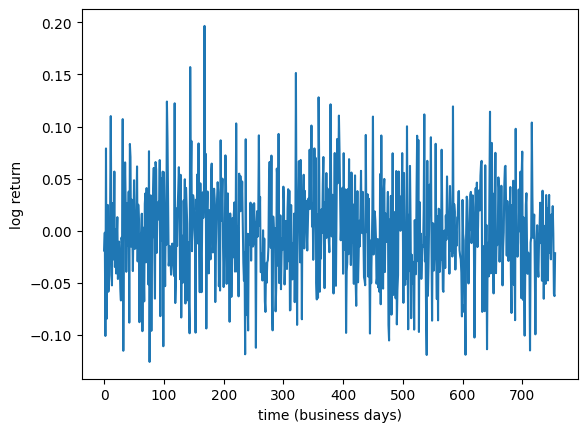

In [ ]:
# generate 3 years of daily log returns
r = 0.5/252             # interest rate (daily)
sigma = 12./252         # volatility (daily)
mu= r - 0.5*sigma**2    # market price of risk
np.random.seed(2)
timeseries = np.random.normal(mu, sigma, 3*252)
plt.plot(timeseries)
plt.xlabel("time (business days)")
plt.ylabel("log return")

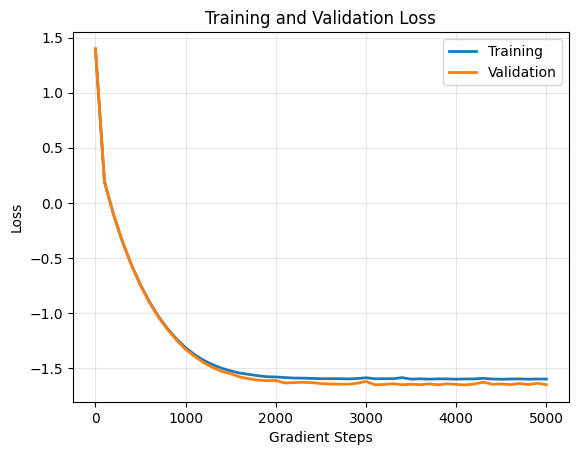

In [ ]:
# input layers: PositionEncoding instead of TokenEmbedding
# output layers: NormalOutput instead of CategoricalOutput
config = {
    "B": 100,                       # batch size
    "D": 2,                         # location and scale of the normal distribution
    "E": 4,                         # 1 signal plus 3 positional encodings
    "F": 3,                         # number of positional encodings
    "T_pred": 252,                  # predict one year
    "output": NormalOutput,         # output a normal instead of categorical distribution
    "dtype": torch.float,           # real instead of integer numbers
    "eval_iters": 100,              # number of batches for evaluation
    "max_iters": 5000,              # number of batches for training
    "split": 2*252,                 # 9 years for training and 1 year for evaluation
    "use_token_embedding": False,   # use raw inputs as tokens
}
torch.manual_seed(1)
encoding = PositionEncoding(**config).to(device)
model = GPT(encoding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

Text(0, 0.5, 'log return')

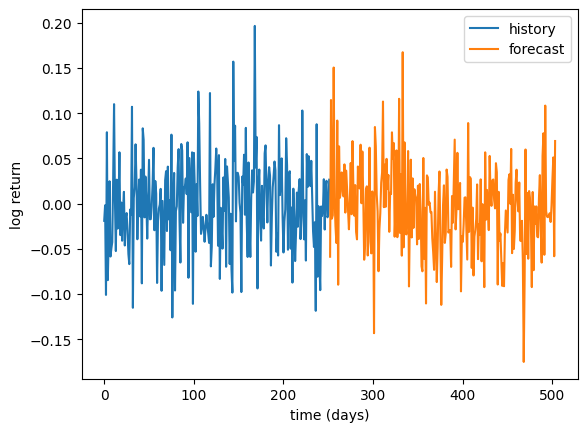

In [ ]:
output = generate(model, timeseries[:252], config)
plt.plot(np.arange(0, 252), timeseries[:252], label="history")
plt.plot(np.arange(252, 2*252), output[252:2*252], label="forecast")
plt.legend()
plt.xlabel("time (days)")
plt.ylabel("log return")

Text(0, 0.5, 'one-step ahead')

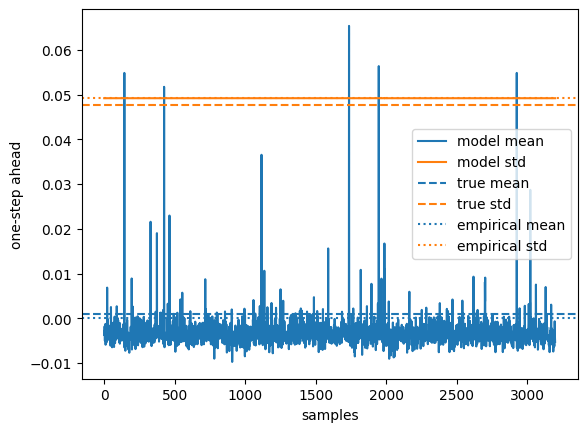

In [ ]:
# has the model learned the correct mu and sigma?
data = torch.as_tensor(timeseries, dtype=torch.float)
split = config["split"]
train_data = data[:split]
val_data = data[split:]
X, Y = get_batch(data, config)
params, _ = model(Y)
output = NormalOutput(params)
plt.plot(output.loc.flatten(0, 1).detach().cpu().numpy(), label="model mean")
plt.plot(output.scale.flatten(0, 1).detach().cpu().numpy(), label="model std")
plt.axhline(mu, color="C0", linestyle="--", label="true mean")
plt.axhline(sigma, color="C1", linestyle="--", label="true std")
plt.axhline(train_data.mean(), color="C0", linestyle=":", label="empirical mean")
plt.axhline(train_data.std(), color="C1", linestyle=":", label="empirical std")
plt.legend()
plt.xlabel("samples")
plt.ylabel("one-step ahead")

The model performs maximum likelihood estimation: it closely reproduces the empirical mean and empirical standard deviation of the data. This is not surprising because the loss function is precisely the negative log-likelihood. The estimates are noisy because the sample size is finite, and they improve or worsen significantly if more or less training data is used.

This architecture can be used to generate classical parametric probability distributions. In principle, more complicated non-parametric distributions can be generated using diffusion layers, as done in text-to-image models as [DALL-E](https://openai.com/dall-e-2/) or [Imagen](https://imagen.research.google). To date, this technique seems unexplored in the context of time series transformers.

## Probabilistic versus deterministic forecasting

To investigate the difference between generative and non-generative models, we adapt the output layer of the GPT model such that it produces point forecasts instead of distributional forecasts. Everything else is kept the same.

💬 Can you guess the prediction of the model?

Text(0, 0.5, 'log return')

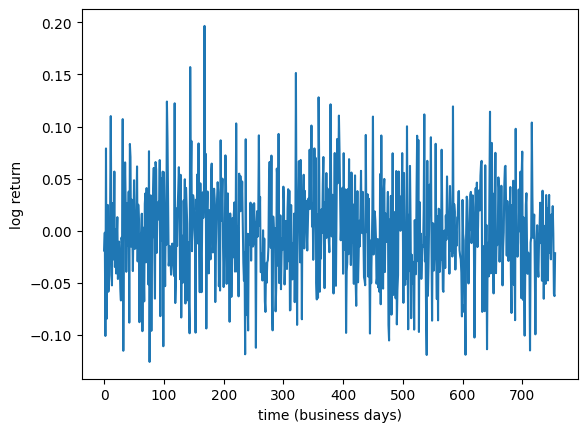

In [ ]:
# generate 3 years of daily log-returns
r = 0.5/252             # interest rate (daily)
sigma = 12./252         # volatility (daily)
mu= r - 0.5*sigma**2    # market price of risk
np.random.seed(2)
timeseries = np.random.normal(mu, sigma, 3*252)
plt.plot(timeseries)
plt.xlabel("time (business days)")
plt.ylabel("log return")

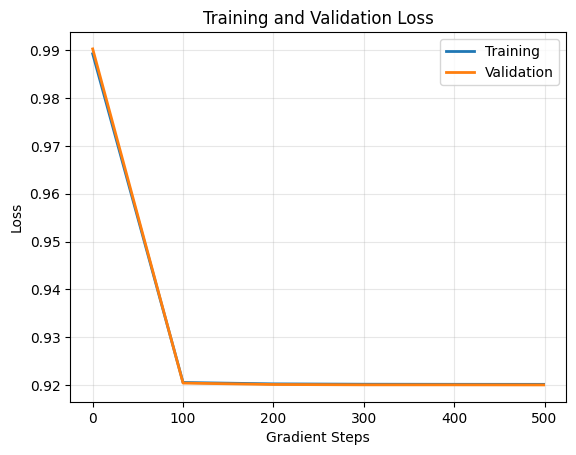

In [ ]:
# train model with scalar output using the mean-square loss function
config = {
    "B": 100,                       # batch size
    "D": 1,                         # location and scale of the normal distribution
    "E": 4,                         # 1 signal plus 3 positional encodings
    "F": 3,                         # number of positional encodings
    "T_pred": 252,                  # predict one year
    "output": ScalarOutput,         # output a scalar point predictions
    "dtype": torch.float,
    "eval_iters": 100,              # number of batches for evaluation
    "max_iters": 500,               # number of batches for training
    "split": 2*252,                 # 2 years for training and 1 year for evaluation
    "use_token_embedding": False,   # use raw inputs as tokens
}
torch.manual_seed(1)
encoding = PositionEncoding(**config).to(device)
model = GPT(encoding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

Text(0, 0.5, 'log return')

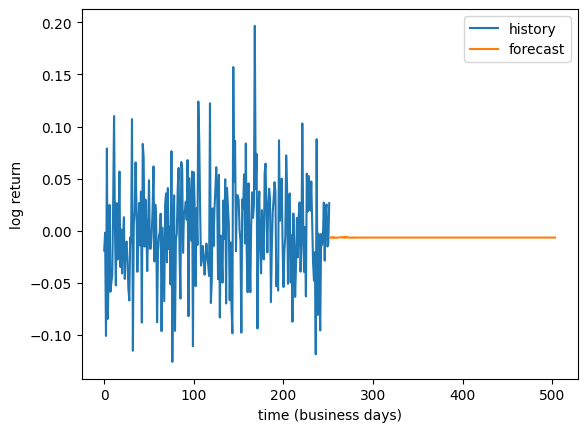

In [ ]:
output = generate(model, timeseries[:252], config)
plt.plot(np.arange(0, 252), timeseries[:252], label="history")
plt.plot(np.arange(252, 2*252), output[252:2*252], label="forecast")
plt.legend()
plt.xlabel("time (business days)")
plt.ylabel("log return")

All noise is filtered out by the model. While this is desired in many applications, it is certainly not desired when the goal is to generate realistic financial time series.

## Handling non-stationarity

The time series of log prices, modeled as cumulative sums of i.i.d. random normals, has integration order 1, meaning that its 1st-order differences are stationary, whereas the time series itself is non-stationary.

💬 Is the ground truth a Markov model? What is the transition kernel?

In [ ]:
# generate 10 years of daily log prices
r = 0.5/252             # interest rate (daily)
sigma = 12./252         # volatility (daily)
mu= r - 0.5*sigma**2    # market price of risk
np.random.seed(3)
timeseries = np.random.normal(mu, sigma, 10*252)
timeseries = np.cumsum(timeseries, axis=-1)

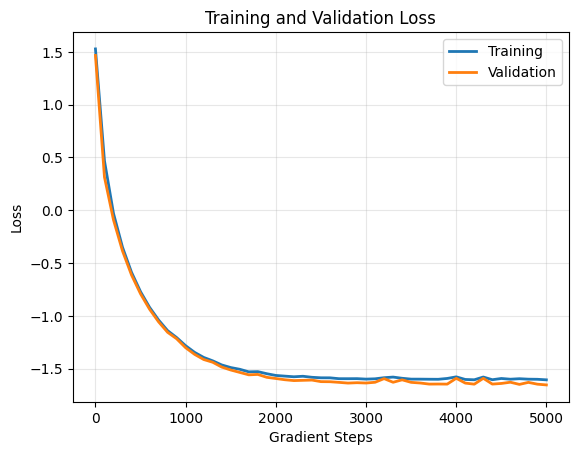

In [ ]:
# train model with normal output
config = {
    "B": 100,                       # batch size
    "D": 2,                         # location and scale of the normal distribution
    "E": 4,                         # 1 signal plus 3 positional encodings
    "F": 3,                         # number of positional encodings
    "T_pred": 252,                  # predict one year
    "output": NormalOutput,         # output a normal instead of categorical distribution
    "dtype": torch.float,
    "eval_iters": 100,              # number of batches for evaluation
    "max_iters": 5000,              # number of batches for training
    "split": 9*252,                 # 9 years for training and 1 year for evaluation
    "use_token_embedding": False,   # use raw inputs as tokens
}
torch.manual_seed(1)
encoding = PositionEncoding(**config).to(device)
model = GPT(encoding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

Text(0, 0.5, 'log price')

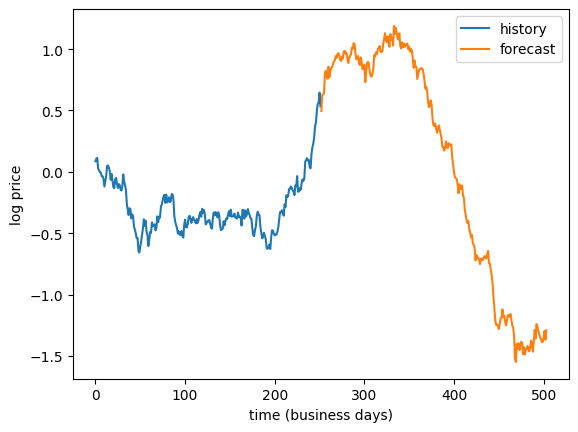

In [ ]:
output = generate(model, timeseries[:252], config)
plt.plot(np.arange(0, 252), timeseries[:252], label="history")
plt.plot(np.arange(252, 2*252), output[252:2*252], label="forecast")
plt.legend()
plt.xlabel("time (business days)")
plt.ylabel("log price")

Text(0, 0.5, 'one step ahead')

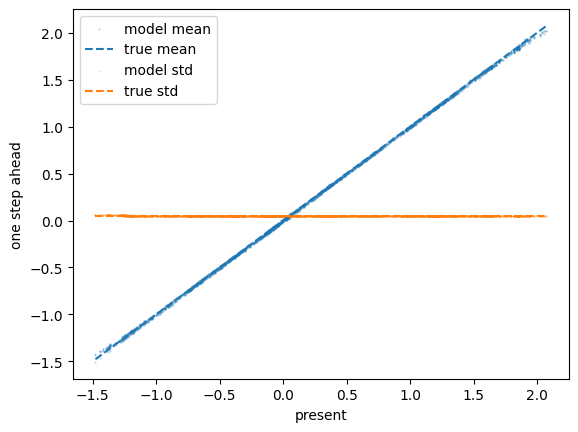

In [ ]:
# has the model learned the correct mu and sigma?
data = torch.as_tensor(timeseries, dtype=torch.float)
split = config["split"]
train_data = data[:split]
val_data = data[split:]
_, samples = get_batch(data, config)
params, _ = model(samples)
model_distribution = NormalOutput(params)
samples = samples.flatten(0, 1).detach().cpu().numpy()
loc = model_distribution.loc.flatten(0, 1).detach().cpu().numpy()
scale = model_distribution.scale.flatten(0, 1).detach().cpu().numpy()
plt.scatter(samples, loc, label="model mean", alpha=0.5, s=0.1)
plt.plot([samples.min(), samples.max()], [samples.min()+mu, samples.max()+mu], label="true mean", linestyle="--")
plt.scatter(samples, scale, label="model std", alpha=0.5, s=0.1)
plt.plot([samples.min(), samples.max()], [sigma, sigma], label="true std", linestyle="--")
plt.legend()
plt.xlabel("present")
plt.ylabel("one step ahead")

The model has learned a linear univariate forecasting function.

## Approximating non-normal distributions

We next attempt to learn prices instead of log prices. As before, we assume that log prices are normally distributed. Hence, prices are log-normally distributed.

Text(0, 0.5, 'stock price')

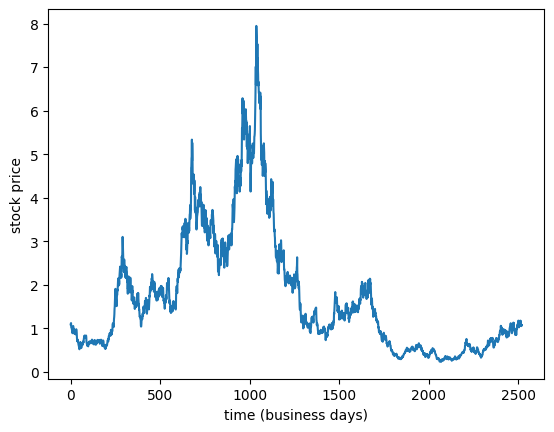

In [ ]:
# generate 10 years of daily stock prices
# these are exponentials of cumulative sums of iid random normals
r = 0.5/252             # interest rate (daily)
sigma = 12./252         # volatility (daily)
mu= r - 0.5*sigma**2    # market price of risk
np.random.seed(3)
timeseries = np.random.normal(mu, sigma, 10*252)
timeseries = np.cumsum(timeseries, axis=-1)
timeseries = np.exp(timeseries)
plt.plot(timeseries)
plt.xlabel("time (business days)")
plt.ylabel("stock price")

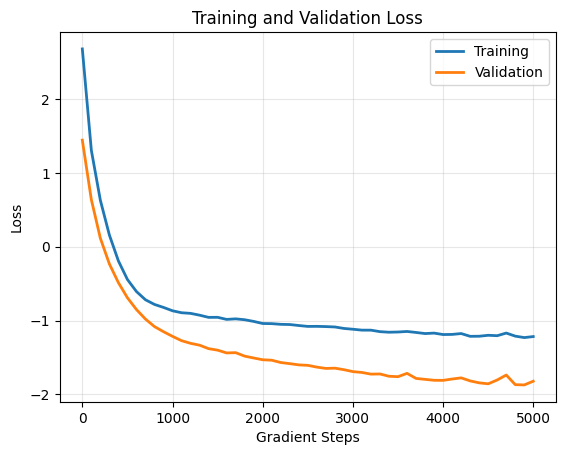

In [ ]:
# train model with normal output
config = {
    "B": 100,                       # batch size
    "D": 2,                         # location and scale of the normal distribution
    "E": 4,                         # 1 signal plus 3 positional encodings
    "F": 3,                         # number of positional encodings
    "T_pred": 252,                  # predict one year
    "output": NormalOutput,         # output a normal instead of categorical distribution
    "dtype": torch.float,
    "eval_iters": 100,              # number of batches for evaluation
    "max_iters": 5000,              # number of batches for training
    "split": 9*252,                 # 9 years for training and 1 year for evaluation
    "use_token_embedding": False,   # use raw inputs as tokens
}
torch.manual_seed(1)
encoding = PositionEncoding(**config).to(device)
model = GPT(encoding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

Text(0, 0.5, 'price')

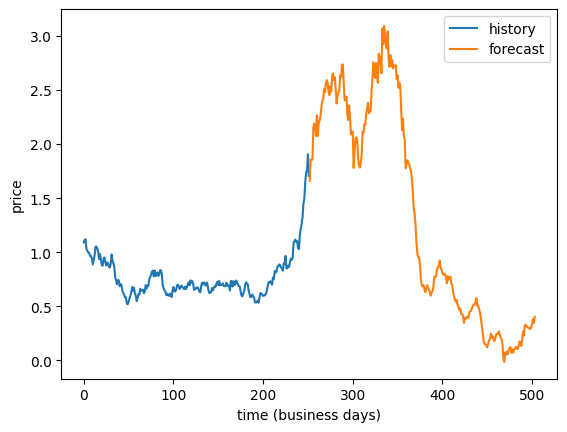

In [ ]:
output = generate(model, timeseries[:252], config)
plt.plot(np.arange(0, 252), timeseries[:252], label="history")
plt.plot(np.arange(252, 2*252), output[252:2*252], label="forecast")
plt.legend()
plt.xlabel("time (business days)")
plt.ylabel("price")

Text(0, 0.5, 'one step ahead')

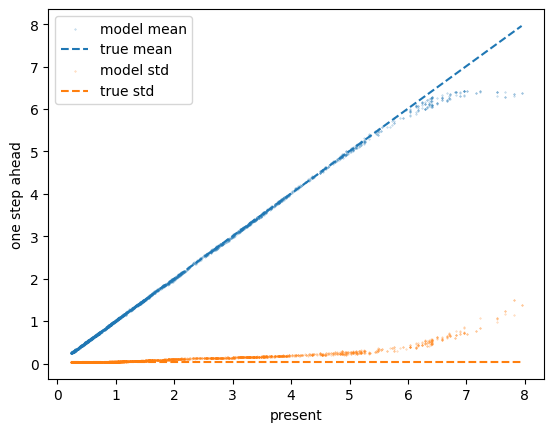

In [ ]:
# has the model learned the correct mu and sigma?
data = torch.as_tensor(timeseries, dtype=torch.float)
split = config["split"]
train_data = data[:split]
val_data = data[split:]
_, samples = get_batch(data, config)
params, _ = model(samples)
model_distribution = NormalOutput(params)
samples = samples.flatten(0, 1).detach().cpu().numpy()
loc = model_distribution.loc.flatten(0, 1).detach().cpu().numpy()
scale = model_distribution.scale.flatten(0, 1).detach().cpu().numpy()
plt.scatter(samples, loc, label="model mean", alpha=0.5, s=0.1)
plt.plot([samples.min(), samples.max()], [samples.min()*np.exp(r), samples.max()*np.exp(r)], label="true mean", linestyle="--")
plt.scatter(samples, scale, label="model std", alpha=0.5, s=0.1)
plt.plot([samples.min(), samples.max()], [np.exp(r)*sigma, np.exp(r)*sigma], label="true std", linestyle="--")
plt.legend()
plt.xlabel("present")
plt.ylabel("one step ahead")

The model has learned a normal approximation of the log-normal data distribution. On small scales, the exponential is well approximated by an affine function (namely, its first-order Taylor series). Therefore, the exponential of a normal random variable with small standard deviation is again approximately normal.

## Forecasting fractional processes

The rough Bergomi model is a stochastic volatility model, which achieves good fits to both realized and implied volatilities despite its low number of model parameters:
$$S_t := \exp \left\{ \int_0^t \sqrt{ V_u } \mathrm{d}B_u - \frac{1}{2}\int_0^t V_u \mathrm{d}u \right\},\quad B_u:=\rho W_u^1 + \sqrt{1 - \rho^2}W_u^2, $$
$$V_t := \xi\ \exp \left\{ \eta Y^a_t - \frac{\eta^2}{2} t^{2a + 1}\right\}, \quad Y_t^a := \sqrt{2a + 1} \int_0^t (t - u)^a  \mathrm{d}W^1_u.$$
The variance process $V$ is the exponential of Volterra fractional Brownian motion with Hurst index $H=a+1/2$.

Text(0, 0.5, 'stock price')

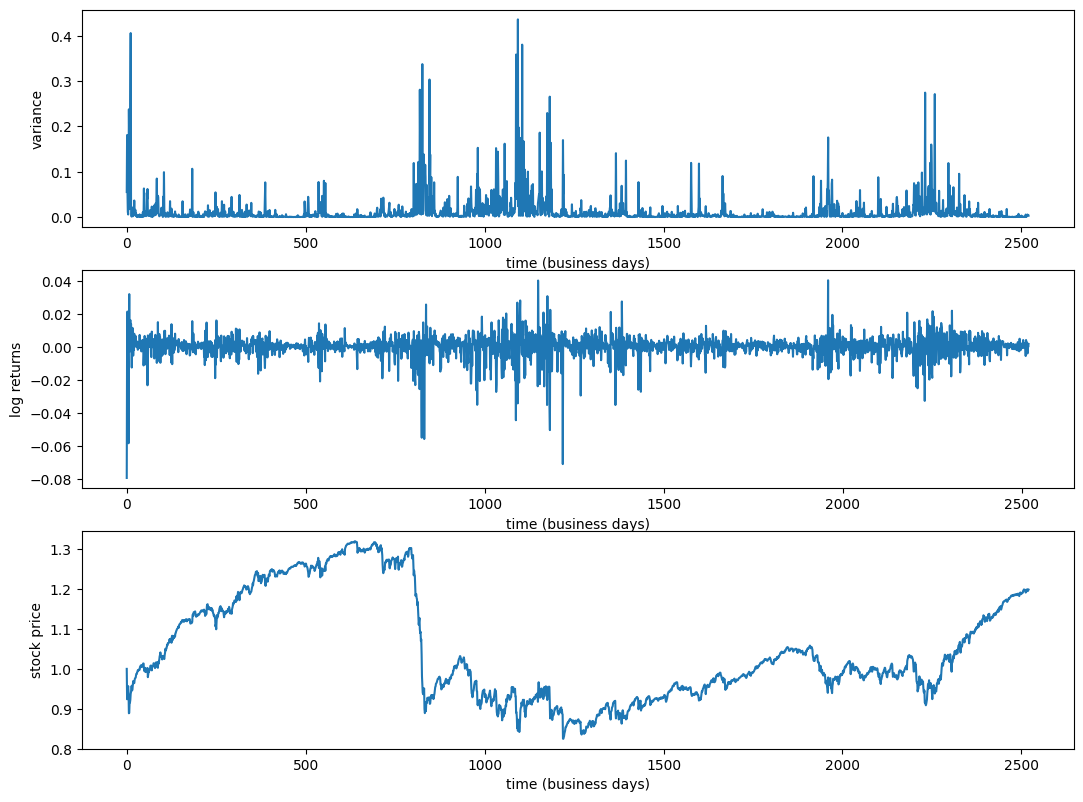

In [ ]:
np.random.seed(0)
rB = rBergomi(n = 10*252, N = 1, T = 10., a = -0.43)  # noqa: N816
dW1 = rB.dW1()  # noqa: N816
dW2 = rB.dW2()  # noqa: N816
Y = rB.Y(dW1)
dB = rB.dB(dW1, dW2, rho = -0.9)  # noqa: N816
V = rB.V(Y, xi = 0.235**2, eta = 1.9)
S = rB.S(V, dB)
I = np.zeros_like(S)
I[:, 1:] = np.cumsum(V[:, :-1], axis=1) * rB.dt

V = V.squeeze(0)[::10]
S = S.squeeze(0)[::10]
I = I.squeeze(0)[::10]

timeseries = np.diff(np.log(S))
variances = np.diff(I)

plt.figure(figsize=(2*6.4, 2*4.8))
plt.subplot(3, 1, 1)
plt.plot(V)
plt.xlabel("time (business days)")
plt.ylabel("variance")
plt.subplot(3, 1, 2)
plt.plot(timeseries)
plt.xlabel("time (business days)")
plt.ylabel("log returns")
plt.subplot(3, 1, 3)
plt.plot(S)
plt.xlabel("time (business days)")
plt.ylabel("stock price")


Forecasting Volterra fractional Brownian motion (fBM) could be implemented as follows:

1. Given a historical trajectory of Volterra fBM, one applies deconvolution with $(t-s)^a$ to recover the underlying Brownian motion.
2. One randomly extends the sample paths of Brownian motion into the future.
3. One applies convolution with $(t-s)^a$ to recover an extended sample path of Volterra fBM.

We next attempt to learn this sequence of operations directly.

Text(0, 0.5, 'Volterra kernel')

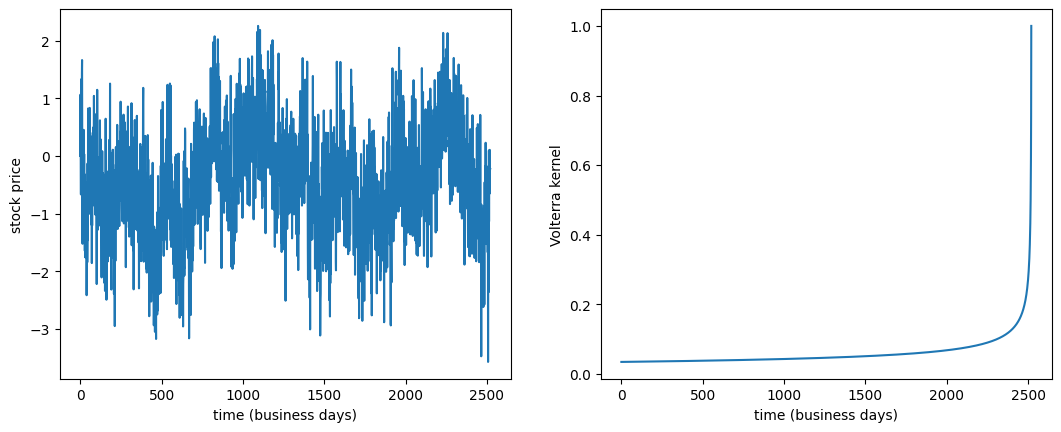

In [ ]:
np.random.seed(0)
rB = rBergomi(n = 10*252, N = 1, T = 10., a = -0.43)  # noqa: N816
dW1 = rB.dW1()  # noqa: N816
Y = rB.Y(dW1)
timeseries = Y.squeeze(0)[::10]
plt.figure(figsize=(2*6.4, 4.8))
plt.subplot(1, 2, 1)
plt.plot(timeseries)
plt.xlabel("time (business days)")
plt.ylabel("stock price")
plt.subplot(1, 2, 2)
plt.plot(np.power(10*252 - np.arange(10*252), rB.a))
plt.xlabel("time (business days)")
plt.ylabel("Volterra kernel")

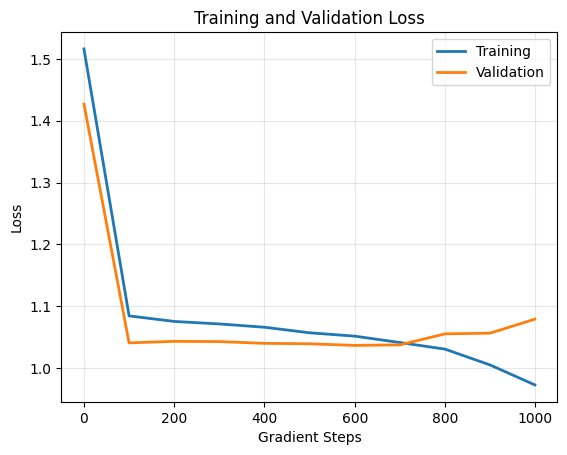

In [ ]:
# train model with normal output
config = {
    "B": 100,                       # batch size
    "D": 2,                         # location and scale of the normal distribution
    "E": 32,                        # 1 signal plus 31 positional encodings
    "F": 31,                        # number of positional encodings
    "T_pred": 252,                  # predict one year
    "output": NormalOutput,         # output a normal instead of categorical distribution
    "dtype": torch.float,
    "eval_iters": 100,              # number of batches for evaluation
    "max_iters": 1000,              # number of batches for training
    "split": 9*252,                 # 9 years for training and 1 year for evaluation
    "use_token_embedding": False,   # use raw inputs as tokens
}
torch.manual_seed(1)
encoding = PositionEncoding(**config).to(device)
model = GPT(encoding, **config).to(device)
print(f"Number of model parameters: {sum(p.numel() for p in model.parameters())/1e6} M")
train(model, timeseries, config)

Text(0, 0.5, 'price')

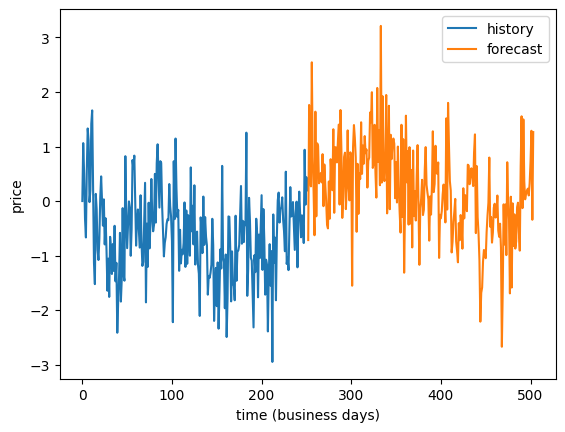

In [ ]:
output = generate(model, timeseries[:252], config)
plt.plot(np.arange(0, 252), timeseries[:252], label="history")
plt.plot(np.arange(252, 2*252), output[252:2*252], label="forecast")
plt.legend()
plt.xlabel("time (business days)")
plt.ylabel("price")

The forecasts are decent. Further training can lead to overfitting in this example.

Text(0, 0.5, 'one step ahead')

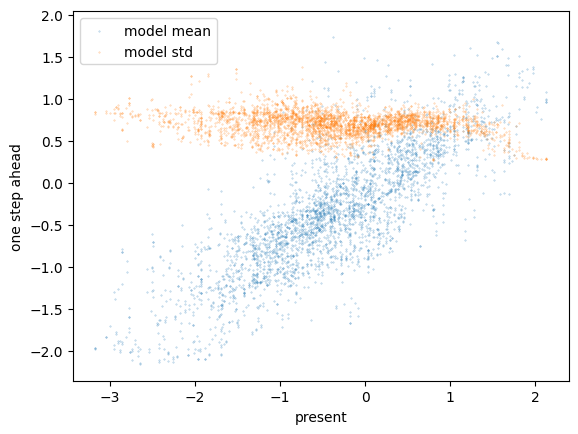

In [ ]:
# has the model learned the correct mu and sigma?
data = torch.as_tensor(timeseries, dtype=torch.float)
split = config["split"]
train_data = data[:split]
val_data = data[split:]
_, samples = get_batch(data, config)
params, _ = model(samples)
model_distribution = NormalOutput(params)
samples = samples.flatten(0, 1).detach().cpu().numpy()
loc = model_distribution.loc.flatten(0, 1).detach().cpu().numpy()
scale = model_distribution.scale.flatten(0, 1).detach().cpu().numpy()
plt.scatter(samples, loc, label="model mean", alpha=0.5, s=0.1)
plt.scatter(samples, scale, label="model std", alpha=0.5, s=0.1)
plt.legend()
plt.xlabel("present")
plt.ylabel("one step ahead")

The forecasted one-step-ahead volatility is approximately constant, as it should be. The forecasted one-step-ahead mean shows a linear trend when plotted against the present value of the time series but has significant additional noise. This is also correct, as the true mean is a Volterra integral operator applied to the given past time series.

## Homework: Implied volatility under the rough Bergomi model

Call prices are often quoted in [implied volatility](https://en.wikipedia.org/wiki/Implied_volatility):
This is the volatility of the unique Black-Scholes model with the given call price.
Implied volatilities form a 2D surface when plotted over a grid of strikes and times to maturity.
Typically, these surfaces are heavily curved, and this curvature is referred to as the smile.
Realistically steep smiles are not easily reproducible by simple stochastic models.
Rough volatility does help, though.
Here is an implied volatility surface over for 1-5 business-day maturities generated by the rough Bergomi model:

In [ ]:
def simulate_rbergomi_batch(
    *,
    n_paths: int,
    n_days: int = 10,
    steps_per_day: int = 24 * 60,
    a: float = -0.40,
    rho: float = -0.7,
    xi: float = 0.20**2,
    eta: float = 1.0,
    s0: float = 1.0,
    seed: int = 123,
) -> np.ndarray:
    np.random.seed(seed)
    business_days_per_year = 252
    steps_per_year = business_days_per_year * steps_per_day
    rB = rBergomi(n=steps_per_year, N=n_paths, T=float(n_days) / business_days_per_year, a=a)
    dW1 = rB.dW1()
    dW2 = rB.dW2()
    Y = rB.Y(dW1)
    dB = rB.dB(dW1, dW2, rho=rho)
    V = rB.V(Y, xi=xi, eta=eta)
    S = rB.S(V, dB, S0=s0)
    return np.diff(np.log(S), axis=1)

In [ ]:
def implied_vol_surface_from_log_returns(
    log_returns: np.ndarray,
    *,
    maturities_days: np.ndarray,
    log_moneyness: np.ndarray,
    steps_per_day: int = 24 * 60,
    s0: float = 1.0,
    option_type: str = "call",
) -> np.ndarray:
    assert log_returns.ndim == 2
    _, n_steps = log_returns.shape
    maturity_idx = np.array([round(t * steps_per_day) for t in maturities_days], dtype=int)
    assert maturity_idx.max() <= n_steps

    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    log_returns_to_maturity = cumulative_log_returns[:, maturity_idx - 1]

    iv_surface = np.full((len(maturities_days), len(log_moneyness)), np.nan)
    for i, ttm_days in enumerate(maturities_days):
        st = s0 * np.exp(log_returns_to_maturity[:, i])
        fwd = s0
        ttm_years = float(ttm_days) / 252.0
        for j, x in enumerate(log_moneyness):
            k = fwd * np.exp(x)
            payoff = np.maximum(st - k, 0.0)
            price = float(payoff.mean())
            try:
                iv_surface[i, j] = bsinv(price, fwd, k, ttm_years, o=option_type)
            except ValueError:
                iv_surface[i, j] = np.nan
    return iv_surface

In [ ]:
maturities_days = np.arange(1, 6, dtype=float)
log_moneyness = np.linspace(-0.10, 0.10, 17)
steps_per_day = 24 * 60
surface_log_returns = simulate_rbergomi_batch(
    n_paths=4096,
    n_days=5,
    steps_per_day=steps_per_day,
    seed=456,
)
implied_volatility_ground_truth = implied_vol_surface_from_log_returns(
    surface_log_returns,
    maturities_days=maturities_days,
    log_moneyness=log_moneyness,
    steps_per_day=steps_per_day,
    s0=1.0,
)

In [ ]:
X, Y = np.meshgrid(log_moneyness, maturities_days)
fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=implied_volatility_ground_truth,
            colorscale="Viridis",
            colorbar={"title": "implied vol"},
        )
    ]
)
fig.update_layout(
    title="Implied volatility surface of the rough Bergomi model",
    scene={
        "xaxis_title": "log-moneyness log(K/F)",
        "yaxis_title": "maturity (business days)",
        "zaxis_title": "implied vol",
    },
    width=900,
    height=650,
)
fig.show()


We shall investigate if a transformer model with centered normal output can reproduce these steep smiles when trained on the following trajectory of per-minute log returns. The trajectory spans a period of 2 months, counted as 2 times 21 business days.

In [ ]:
timeseries = simulate_rbergomi_batch(
    n_paths=1,
    n_days=42,
    steps_per_day=24 * 60,
)[0]
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=timeseries,
        mode="lines",
        line={"width": 1},
        name="log return",
    )
)
fig.update_layout(
    title="Training data: per-minute log returns over 42 business days",
    xaxis_title="time step (minutes)",
    yaxis_title="log return",
    width=900,
    height=320,
)
fig.show()

**Task 1.** The context window must be sufficiently small for the samples within any given batch to be reasonably independent. To investigate this, choose a context window and check how many non-overlapping context windows fit into the 2-month range of training data. The batch size should be of the same order of magnitude.

**Task 2.** The context window must be sufficiently large for the standard deviation of the log returns to be estimated with reasonable accuracy. To investigate this, you may compute $\operatorname{std}(\hat\sigma_n)$ for the empirical variance estimator $\hat \sigma_n^2=\frac1n\sum_{i=1}^n X_i^2$ of iid. centered normal observations $X_i$, where $n$ is the size of the context window.

**Task 3.** What is the expected loss of the empirical estimator $\hat \sigma_n$ evaluated on the same sliding windows of the training data as the model? You may later compare this to the loss of your trained model.

**Task 4:** Fit a transformer model with centered normal output to the given training data.

In [ ]:
config = ...
encoding = ...
model = GPT(...)
train(model, timeseries, config)

**Task 5.** Report on your experience with fitting the model and on any encountered failures or fixes.

Here is the model's predicted standard deviation compared to the empirical standard deviation estimated on the same sliding context window.

In [ ]:
class EmpiricalEstimator(Module):
    def forward(self, x: Tensor, targets: Tensor | None = None) -> tuple[Tensor, Tensor | None]:
        # Match GPT-style contract: logits of shape (B, T, 1) and optional loss.
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        if targets is not None and targets.ndim == 2:
            targets = targets.unsqueeze(-1)

        # One centered-normal MLE sigma per context window.
        sigma = torch.sqrt(x.square().mean(dim=1, keepdim=True)).clamp_min(1e-3).expand_as(x)
        dist = torch.distributions.Normal(loc=torch.zeros_like(sigma), scale=sigma)
        loss = None if targets is None else -dist.log_prob(targets).mean()
        return sigma, loss

In [ ]:
window = config["T_max"]
x = np.lib.stride_tricks.sliding_window_view(
    np.asarray(timeseries, dtype=float).reshape(-1)[:-1],
    window,
).copy()
x = torch.as_tensor(x, dtype=config["dtype"], device=config["device"]).unsqueeze(-1)

empirical_estimator = EmpiricalEstimator().to(config["device"])
empirical_estimator.eval()
with torch.inference_mode():
    empirical_sigma = empirical_estimator(x)[0][:, -1, 0].detach().cpu().numpy()

model.eval()
model_sigma = np.empty(x.shape[0], dtype=float)
batch_size = 512
with torch.inference_mode():
    for i in range(0, x.shape[0], batch_size):
        logits, _ = model(x[i : i + batch_size])
        model_sigma[i : i + batch_size] = model.distribution(logits).scale[:, -1].detach().cpu().numpy()

t_idx = np.arange(window, len(timeseries))
fig = go.Figure()
fig.add_trace(go.Scatter(x=t_idx, y=empirical_sigma, mode="lines", line={"width": 1}, name="empirical sigma"))
fig.add_trace(go.Scatter(x=t_idx, y=model_sigma, mode="lines", line={"width": 1}, name="model sigma"))
fig.update_layout(title=f"Predicted vs empirical sigma (window={window})", xaxis_title="time step", yaxis_title="sigma")
fig.show()

Compute the implied-volatility surface of the fitted model: (this may take a couple of minutes)

In [ ]:
n_model_paths = 100
seed_context = timeseries[-config["T_max"] :]
seed_context_batch = np.repeat(seed_context[None, :], n_model_paths, axis=0)
torch.manual_seed(1000)
generated_full_batch_scaled = np.array(generate(model, seed_context_batch, config), dtype=float)
model_log_returns = generated_full_batch_scaled[:, -(5 * steps_per_day):]

In [ ]:
implied_volatility_predicted = implied_vol_surface_from_log_returns(
    model_log_returns,
    maturities_days=maturities_days,
    log_moneyness=log_moneyness,
    steps_per_day=steps_per_day,
    s0=1.0,
)

Plot and compare the ground-truth rough-Bergomi volatility surface to the model-predicted volatility surface:

In [ ]:
iv_diff = implied_volatility_predicted - implied_volatility_ground_truth

iv_vmin = np.nanmin(np.stack([implied_volatility_ground_truth, implied_volatility_predicted]))
iv_vmax = np.nanmax(np.stack([implied_volatility_ground_truth, implied_volatility_predicted]))

plt.figure(figsize=(15, 4.2))
plt.subplot(1, 3, 1)
plt.imshow(
    implied_volatility_ground_truth,
    origin="lower",
    aspect="auto",
    vmin=iv_vmin,
    vmax=iv_vmax,
    extent=[log_moneyness[0], log_moneyness[-1], maturities_days[0], maturities_days[-1]],
)
plt.title("Ground-truth (rough Bergomi)")
plt.xlabel("log-moneyness")
plt.ylabel("maturity (business days)")
plt.colorbar(label="implied vol")

plt.subplot(1, 3, 2)
plt.imshow(
    implied_volatility_predicted,
    origin="lower",
    aspect="auto",
    vmin=iv_vmin,
    vmax=iv_vmax,
    extent=[log_moneyness[0], log_moneyness[-1], maturities_days[0], maturities_days[-1]],
)
plt.title("Prediction (transformer model)")
plt.xlabel("log-moneyness")
plt.ylabel("maturity (business days)")
plt.colorbar(label="implied vol")

plt.subplot(1, 3, 3)
plt.imshow(
    iv_diff,
    origin="lower",
    aspect="auto",
    cmap="coolwarm",
    extent=[log_moneyness[0], log_moneyness[-1], maturities_days[0], maturities_days[-1]],
)
plt.title("Difference (model - ground truth)")
plt.xlabel("log-moneyness")
plt.ylabel("maturity (business days)")
plt.colorbar(label="vol difference")
plt.tight_layout()

print(f"Mean absolute IV difference: {np.nanmean(np.abs(iv_diff)):.6f}")


## Attention mechanisms

The attention mechanism has been the main area of improvements of the transformer architecture, the reason being that it is the bottleneck in terms of both information flow and computational complexity:

- **Information flow:** Significant model improvements have been achieved by spreading attention over more tokens, higher-dimensional tokens, and patches of tokens. For many datasets, the receptive field of the attention mechanism seems too narrow and too local. In time series analysis, a single time step may not have semantic meaning like a word in a sentence.
- **Computational complexity:** Widening the receptive field is impeded by computational limitations. The computational complexity of an attention head is $O(dn^2)$, where $d$ and $n$ are the embedding dimension and number of tokens, respectively. Consequently, even moderate increases of these quantities drastically increase the training and inference times. For BERT and GPT style models, it has been estimated that attention requires between 50 and 80 % of the overall compute.

As remedies of the above dilemma, many architectural modifications have been proposed. On the one hand, there are several proposals for introducing sparsity in the attention mechanism:

- [LogSparse](https://doi.org/10.48550/arXiv.1907.00235): spread attention into the past on an exponential scale
- [Linformer](https://doi.org/10.48550/arXiv.2006.04768): apply Johnson-Lindenstrauss projections to queries, keys, and values
- [Performer](https://doi.org/10.48550/arXiv.2009.14794): kernelize the inner product and use hand-crafted projections
- [Reformer](https://doi.org/10.48550/arXiv.2001.04451): apply locality-sensitive hashing to the inner product
- [Informer, ProbSparse](https://doi.org/10.48550/arXiv.2012.07436): attend only to a small number of dominant queries

On the other hand, there are several proposals for attending to non-local features:

- [Patching](https://doi.org/10.48550/arXiv.2211.14730): attend to patches of subsequent values
- [Autoformer](https://doi.org/10.48550/arXiv.2106.13008): attend to auto-correlation between queries and keys
- [Convolution](https://doi.org/10.48550/arXiv.1907.00235), [causal convolution](https://doi.org/10.1016/j.neucom.2022.01.039): attend to weighted averages
- [Scaleformer](https://doi.org/10.48550/arXiv.2206.04038): attend to multi-scale features
- [Stationarization](https://doi.org/10.48550/arXiv.2205.14415): attend to normalized features
- [FEDFormer](https://doi.org/10.48550/arXiv.2201.12740): attend to Fourier features
- [CrossFormer](https://openreview.net/pdf?id=vSVLM2j9eie): cross-time and cross-variate attention
- [iTransformer](https://doi.org/10.48550/arXiv.2310.06625): cross-variate attention only, i.e., a single patch

Finally, there are proposals for discarding attention altogether:

- [MLP Mixers](https://doi.org/10.48550/arXiv.2105.01601) replace attention by a feed-forward neural network, which is applied identically to each spatial feature. They perform nearly as well as attention networks on vision tasks and better than attention networks on [memory-constrained NLP tasks](https://arxiv.org/abs/2202.04350).

## Is attention all you need?

The assumptions of temporal causality and homogeneity place time series analysis firmly in the framework of supervised learning.
[Statistical learning theory](https://link.springer.com/book/10.1007/978-1-4757-3264-1), going back to a series of results by Vapnik and Chervonenkis in the late 60s to 70s, sheds light on what assumptions are necessary and sufficient for learning.

💬 What is supervised learning? Is anyone familiar with statistical learning theory?

The starting point of statistical learning theory is the observation that learning is impossible without any prior assumptions on the function to be learned. Indeed, infinitely many functions may perfectly interpolate any finite set of samples, and a learning algorithm has no way of knowing which interpolation is the correct one:

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_generalization.png" width="1000px"/>

In principle, this problem can be overcome by narrowing down the hypothesis class of functions.
However, unfortunately, no single hypothesis class fits all kinds of data.
Even worse, any improvement for one kind of data is offset by deterioration for another kind of data,
by the following result of [Wolpert and Macready (1997)](https://doi.org/10.1109/4235.585893):

**Theorem (No-Free-Lunch Theorem for Optimization).**
Let $\mathcal X$ and $\mathcal Y$ be finite sets,
let $f^*: \mathcal X \to \mathcal Y$ be chosen uniformly at random,
let $S \subset X$ be a finite set of training points,
and let $f: \mathcal X \to \mathcal Y$ be an estimator for $f^*$ given samples $\{(x, f^*(x)): x \in S\}$.
Then, the algorithm performs as badly as random guessing on unseen point:
$$\forall x \notin S: \qquad P[f(x)=f^*(x)]=\frac{1}{|Y|}.$$

**Proof.** The algorithm must choose a prediction $f(x)$, but under the chosen model for $f^*$, any outcome $f^*(x)$ is equally likely, regardless of the observed samples. $\square$

**Example (Language Modeling).**
$n$-gram models are language models with a context window of size $n-1$.
For example, a bigram model ($n=2$) looks only at the last token to determine the next one.
To empirically estimate an $n$-gram model, one must count all $n$-grams within the corpus of training data.
As the number of possible $n$-grams grows exponentially in $n$, some $n$-grams will be missing, even for moderate choices of $n$,
and the empirical transition probabilities of these $n$-grams are ill defined.
As a remedy, one may apply a [smoothing technique](https://en.wikipedia.org/wiki/Word_n-gram_language_model) such as,
in the simplest case, assigning a count of 1 to all missing $n$-grams.
Alternatively, one may narrow down the hypothesis class of possible transition probabilites,
or define a prior on the set of possible transition probabilities, for example by specifying a neural network architecture.
Without any such inductive bias, the model can't be expected to generalize well to unseen input.

To date, there is no principled solution to this problem, and the search for good hypothesis classes proceeds by careful trial and error.
Some widely used hypothesis classes in time series analysis are:

- **Classical hidden Markov models** like AR, MA, ARMA, ARIMA, ARCH, GARCH, etc. use a low-dimensional hidden state with highly structured dynamics and readout. Model selection requires significant effort and calibration is notoriously unstable but interpretability is great.
- **Recurrent neural networks** like vanilla RNN, LSTM, GRU, etc. also pass low-dimensional hidden states from one time step to the next. However, compared to classical hidden Markov models, they impose less structure on the dynamics and readout. This eases model selection, but calibration still lacks robustness, and interpretability is bad.
- **Convolutional neural networks** are built from linear operators on multi-dimensional inputs which share weights across patches of consecutive elements. This reduces the number of model parameters while retaining enough flexibility for learning general Fourier or wavelet features.
- **Reservoir computers** like echo state or signature networks use high-dimensional hidden states with randomly selected untrainable dynamics; only the readout is learned. Model selection and calibration are reduced to linear regression. Truncated signatures are somewhat interpretable, but randomized signatures and echo states are not.
- **Transformers** can be seen as hidden Markov models where the hidden state is the context window, which comprises historical data spanning a certain number of time steps. This hidden state is high-dimensional, highly structured (namely, as structured as the input data itself), and easily interpretable (it coincides with the input data). Model selection is not needed thanks to universality, but calibration can be unstable.

These regularity, sparsity, or structural assumptions narrow down the hypothesis class of to-be-learned functions.
A good measure of the size or capacity of the hypothesis class is given by covering numbers.

**Definition (Covering Number).** The covering number $N(\mathcal H, \epsilon)$ of a metric space $\mathcal H$ is the minimal number of $\epsilon$-balls which cover all of $\mathcal H$.

<img src="https://gist.githubusercontent.com/philipp-harms/1977bda4dd3f7e4e8de2fe5518ca78ce/raw/lecture_10_covering_number.png" width="500px"/>

Any metric space with finite covering numbers is totally bounded, and together with completeness this is equivalent to compactness.
In this sense, covering numbers are quantitative measures of compactness.

**Examples (Covering Number).**

- Finite sets have bounded covering numbers.
- The unit ball in $d$ dimensions has covering numbers $N\lesssim\epsilon^{-d}$.
- The unit ball in the Sobolev space $H^s$ or the Hölder space $C^s$, endowed with the uniform norm, has covering numbers $\log N\lesssim \epsilon^{-d/s}$.

Statistical learning theory asserts that lower covering numbers translate into tighter estimation error bounds.
This can be stated as follows; see Theorem 3.3 in [Cucker and Zhou (2007)](https://www.cambridge.org/ch/universitypress/subjects/computer-science/pattern-recognition-and-machine-learning/learning-theory-approximation-theory-viewpoint?format=HB&isbn=9780521865593).

**Theorem (Estimation Error Bound).**

- Let $\mathcal X$ be a compact metric space,
  let $\mathcal Y=\mathbb R$,
  and let $P$ be a probability measure on $\mathcal X\times \mathcal Y$.

- Let $\mathcal H$ be a convex subset of $C(\mathcal X, \mathcal Y)$ such that $P[\sup_{f \in \mathcal H} |f(x)-y|\leq M]=1$, for some finite number $M$.

- For any $f \in \mathcal H$ and any $n$-sample $(x_1, y_1), \dots, (x_n, y_n) \in \mathcal X \times \mathcal Y$,
  define the risk $R(f)$ and the empirical risk $R_n(f)$ as
  $$
  R(f) = \int(f(x)-y)^2 P(x, y),
  \qquad
  R_n(f) = \frac1n\sum_{i=1}^n (f(x_i)-y_i)^2.
  $$

- Let $f^*$ be a risk minimizer, and let $f_n$ be an empirical risk minimizer, i.e.,
  $$
  f^* \in \operatorname*{argmin}_{f \in \mathcal H} R(f),
  \qquad
  f_n \in \operatorname*{argmin}_{f \in \mathcal H} R_n(f).
  $$

- Then, the empirical risk minimizer $f_n$, seen as a random variable on $P^n$, satisfies the error bound
  $$
  P^n[R(f_n)-R(f^*)>\epsilon]
  \leq
  N\Big(\mathcal H, \frac{\epsilon}{12M}\Big)\exp\Big(-\frac{n\epsilon}{300M^2}\Big).
  $$

Bounds with a left-hand side as above are called probably-approximately-correct (PAC) bounds.
The form of the right-hand side is typical for concentration inequalities and large deviations theory, and these are indeed the basis for the proof.
For any fixed confidence level $\epsilon$, the convergence is exponential in the number $n$ of samples.
For finite hypothesis sets, the covering number is bounded, and integration over $\epsilon$ shows that $\|R(f_n)-R(f^*)\|_{L^p} = O(n^{-1})$.
If $R$ is quadratic around its minimum $f^*$, this implies the typical Monte-Carlo rate $\|f_n-f^*\|_{L^p} = O(n^{-1/2})$.
For larger hypothesis classes with potentially unbounded covering numbers, the rate is lower.

The takeaway is that any choice of model architecture narrows down the hypothesis class of forecasting functions and that supervised learning is impossible without any such assumptions. Empirically, different assumptions work better with different types of data, and hence a one-size-fits-all approach to time series analysis is unlikely to exist. In the context of transformers, this suggests that attention is emphaticallly _not_ all you need.